In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import scipy.stats as sps
from pathlib import Path
import os
import re
%matplotlib widget

In [3]:
# atention to the / at the end so i can directly add figures_dir+"toto.pdf"
figure_dir = "/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Figures/"#"/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Figures"

In [4]:
from data_analysis import *
from data_extraction import *

In [5]:
# for i in Path("/home/erdi/Uni/LCGAStage/1DLatticeGaz/OutMonet").rglob('mass*.dat'):
#     print(i)

In [6]:
def getAllCAData(base_dir = Path('.'),  
                 exclude_folders = {'OutCstm', "OutTenThou", 'Out1', 'Out2', 'tmp'},
                 rho = 1,
                 file_dim_to_SI = 1e-18, get_from_dir = False,
                 file_name_regex = "mass*.dat"):
    all_data_list = np.array([])
    all_dirs = None
    
    if get_from_dir:
        all_dirs = Path(get_from_dir).rglob(file_name_regex)
    else: 
        all_dirs = base_dir.rglob(file_name_regex)
    
    for file_path in all_dirs:
        parent_folder = file_path.parent.name
        if parent_folder in exclude_folders:
            continue
        try:
            if os.path.getsize(file_path) > 0:
                data = np.loadtxt(file_path, delimiter=" ")
                if data.size > 1:
                    all_data_list = np.append(all_data_list, data)
    
        except Exception as e:
            print(f"Skipped {file_path} due to error: {e}")
    return massToRadius(all_data_list*file_dim_to_SI, rho=rho)*2


def getDataFromFolder(base_dir = Path('.'),  
                      exclude_folders = {'OutCstm', "OutTenThou", 'Out1', 'Out2', 'tmp'},
                      get_from_dir = False,
                      file_name_regex = "radius*.dat"):
    all_data_list = np.array([])
    all_dirs = None
    
    if get_from_dir:
        all_dirs = Path(get_from_dir).rglob(file_name_regex)
    else: 
        all_dirs = base_dir.rglob(file_name_regex)
    
    valid_files = [
        file_path for file_path in all_dirs 
        if file_path.parent.name not in exclude_folders
    ]
    
    def extract_file_number(file_path):
        match = re.search(r'\d+', file_path.name)
        return int(match.group()) if match else float('inf')
    
    valid_files.sort(key=extract_file_number)
    
    collected_data = []
    
    for file_path in valid_files:
        try:
            if os.path.getsize(file_path) > 0:
                data = np.loadtxt(file_path, delimiter=" ")
                if data.size > 1:
                    collected_data.append(data)
                    
        except Exception as e:
            print(f"Skipped {file_path} due to error: {e}")
            
    # Combine everything at the end
    if collected_data:
        all_data_list = np.concatenate(collected_data)
    else:
        all_data_list = np.array([])
        
    # for file_path in all_dirs:
    #     parent_folder = file_path.parent.name
    #     if parent_folder in exclude_folders:
    #         continue
    #     try:
    #         if os.path.getsize(file_path) > 0:
    #             data = np.loadtxt(file_path, delimiter=" ")
    #             if data.size > 1:
    #                 all_data_list = np.append(all_data_list, data)
    
    #     except Exception as e:
    #         print(f"Skipped {file_path} due to error: {e}")
    return all_data_list

In [7]:
from myprobs import *

In [8]:
exp_dia_11mm_init      = np.array(initL11mmdia_x)#np.array([14.247007681772178, 13.09325314118978, 14.672780325135472, 15.217650211397611, 15.348657178586317, 16.85672601679272, 19.2997082117549, 20.46537247662717, 22.35157506103734, 23.630381706663492, 27.049961293396056, 28.663728934675177, 31.39403322813078, 35.18876912999465, 39.51051033168582, 44.91752515929257, 49.79753468707201, 54.396176978502965, 60.01607812779136, 65.65979872565951, 70.9715357589472, 77.18841183826596, 83.53629488477344, 91.9564699577205, 97.98874531054607, 102.39534329780268, 104.1996665277199, 107.47781813851012, 111.28595248020011, 112.91907342345027, 116.22699934496521, 118.62680878937655, 122.37837194068959, 124.42088965640448, 128.41809087119634, 131.95081283868282, 135.42100875364736, 135.42100875364736, 138.08283213243615, 141.55005061632826, 145.59340201274344, 149.01149288393975, 151.5110462692789, 155.13457988447573, 158.35169415828025, 169.27588876317517, 174.08592866075153, 183.96951110581793, 199.09039480736024, 203.26773060203658, 207.82915500506166, 212.72851783481212, 131.08884654320258, 133.58542249746918, 146.89007324480443, 153.8676829631394, 149.01149288393975, 160.93014946703985, 164.2678496992795, 116.22699934496521, 114.19192520693149, 112.22086583695591, 109.23152504019534, 109.82998868576196])
exp_prob_vol_11mm_init = np.array(initL11mmdiaPDFByVOlume_y)#np.array([5.4483768090897e-10, 1.6132967838811502e-9, 5.341766794686502e-9, 1.6445572657123693e-8, 4.665897805114962e-8, 7.737316156191386e-8, 6.170671358089853e-7, 0.0000021514698259439456, 0.000005699253330050248, 0.000010951704287118268, 0.00002626618722343994, 0.0000533112355948408, 0.00008571503010246286, 0.00010409493036993739, 0.0001109867016666351, 0.0000504115987484143, 0.00002444638829128615, 0.000014425139975557353, 0.00000700039357956249, 0.000003734883590567636, 0.0000024211204963445165, 0.0000017404964521994751, 0.0000014682523941742542, 0.0000026313805765215874, 0.00000965267036102777, 0.00003186730839053875, 0.00008909798123614594, 0.0011532715328412982, 0.012494787097485544, 0.025033943561472358, 0.03904475843945074, 0.04266417698281965, 0.04369758967206432, 0.03359962241418188, 0.019274784286240004, 0.009872604213802146, 0.010774622099539987, 0.010774622099539987, 0.012157656747305366, 0.01150481891163127, 0.010571319137500725, 0.00663379773777608, 0.005668368480544523, 0.006844444500925492, 0.00741707581860701, 0.0038863214280709193, 0.002437584246229745, 0.000655395267652338, 0.000051866475143420256, 0.00002047450644998264, 0.00000705445425733671, 0.000002229838416492918, 0.012461266229545182, 0.00869625643086458, 0.008734568594171528, 0.00588130211097783, 0.00663379773777608, 0.006143355078891901, 0.00484225727860099, 0.03904475843945074, 0.031706228815980106, 0.016471699325177194, 0.00548788261701851, 0.007509116928074466])
ind = np.argsort(exp_dia_11mm_init)
exp_dia_11mm_init = exp_dia_11mm_init[ind]
exp_prob_vol_11mm_init = exp_prob_vol_11mm_init[ind]

exp_111mmx = L111mmdia_x#[10.765145647947657, 11.000648026679736, 12.674453523842649, 14.948869114416222, 16.87398251908518, 17.944016817082613, 19.230586859283378, 21.31533610456938, 24.23777837487552, 27.11754571749198, 31.508321610899483, 35.315873492547695, 38.74883434225291, 41.1639191389148, 44.217547298044856, 46.928195482779884, 49.10303624207748, 52.1250533436596, 54.90366530212268, 57.769207668842554, 58.96726674990912, 59.156933095196685, 61.78697308318449, 64.02345540470057, 66.2283266686687, 69.55539047558835, 71.41886231803885, 73.4704199528995, 75.97085460494078, 81.81415859267572, 86.31083152886879, 89.0831212758223, 93.24471700200728, 97.53907916989361, 102.45775972435158, 104.68475872860327, 108.54288830232814, 112.57171758681184, 115.15276043560037, 116.82498537988587, 119.2669395754635, 119.76955539047557, 122.99230270748707, 124.27255053817821, 126.71766583951063, 126.71766583951063, 128.07694131407163, 131.90504038312602, 135.165720969195, 138.72828715484673, 142.07431759629517, 144.4024719847002, 146.4935434414958, 148.315920909134, 150.30741753465358, 151.65088748044064, 154.44846607343246, 156.76239548594097, 159.90611515908265, 162.57408841612795, 164.15148018776966, 166.41009024956927, 168.40790908659847, 170.5416554710838, 172.45886611136575, 174.35711011711894, 176.9745056820876, 178.81743033713192, 180.0044255480567, 181.16929301869794, 182.10656087499405, 185.25028054813572, 186.87825001185413, 188.6468886816608, 190.65102973019964, 191.6167475382889, 193.34745293903808, 195.563388073148, 196.94637184086994, 198.75768543836634, 199.15440421059284, 201.40036984937328, 204.1600151733076, 205.76901800249723, 207.2942515291849, 210.30362420774784, 212.74241729757068, 215.00576901800252, 216.28285574293886, 218.15106924402153, 221.4797136038186, 223.7541291943922, 226.07754192416505, 228.17019393383805, 230.9472253394237, 233.06674674801246, 236.64827956819292, 239.85680190930788, 244.0041726595963, 246.78910682956894, 249.5392688362389, 252.77624112914694, 256.8177148366498, 261.26855173939845, 264.91962888618434, 269.79721506583, 274.22276312254024, 278.3211367336294, 281.10765145647946, 285.42572191752674, 289.72956740267745, 292.8638037585547, 295.7593766299451, 298.1254642874077, 301.57581121876433, 304.07624587080556, 306.9623354249316, 309.91796930566306, 313.2624191942341, 317.30863456036917, 320.3448766378479, 324.0291453950592, 326.10757242883557]
exp_111mmy = L111mmdiaPDFByVolume_y#[1.4601731235086101e-8, 2.8862382712691874e-8, 5.453811327343811e-8, 9.842710002491877e-8, 1.674120211725579e-7, 2.3377588389936027e-7, 3.1617661220424305e-7, 4.267923992855603e-7, 5.909083241086591e-7, 8.262191220945483e-7, 0.0000011991068434883336, 0.0000018800780130270021, 0.0000018192793505817888, 0.0000017870754026375892, 0.000002395491613488773, 0.000003308920760139195, 0.0000041003481111833454, 0.0000054757361667517935, 0.0000073162599343975, 0.000005447462509926801, 0.000004555886688744718, 0.000003309777355453302, 0.000004024639417365102, 0.000005258354289850845, 0.000007987248788741514, 0.000011691479923729464, 0.00001371248099155567, 0.000011512798431040925, 0.000009364296206660528, 0.000014470981576696855, 0.000025710562015587704, 0.000017189086190467575, 0.00002478913111484302, 0.00003105798163315565, 0.0000412670055572655, 0.000029479625544466016, 0.00005669359421941823, 0.00010197347023887806, 0.00015955333343147806, 0.00027983291724096616, 0.00044932316169946166, 0.0002331564703485923, 0.00038598661038677883, 0.0001931376071735288, 0.00013908191537241585, 0.00009328612373634081, 0.00006733371601339995, 0.0001013419557782634, 0.00007369000635759915, 0.00013811330112745726, 0.0002352174416055295, 0.000344615846965563, 0.00024166664037669628, 0.0004580718374393223, 0.0006808293171410427, 0.00048016754236171753, 0.0003385594480799361, 0.0005620775649899296, 0.0008334684958785485, 0.0005884280849768141, 0.0008374691801037895, 0.0012811723741084592, 0.0017699275295927784, 0.001327075907557045, 0.000984398393352424, 0.0016743368912466748, 0.002469626705096242, 0.0019103695516394443, 0.0014482222992072392, 0.0023014349667816432, 0.0027514640111743088, 0.0039190113104674296, 0.0027891092839537964, 0.0020335983592494424, 0.0033444400296258428, 0.0045496998287893, 0.005948214828404023, 0.004703572523931304, 0.0036070160628115036, 0.0046914134914327445, 0.00596363119226516, 0.007465956619563907, 0.005779746313745252, 0.004540288384503472, 0.007396709898231171, 0.009670356540811475, 0.007722455045039221, 0.006796408264035021, 0.009452574790149064, 0.01182156988225162, 0.01043768989418117, 0.009736916309901386, 0.013051884283777454, 0.011783382851317378, 0.011886002895459151, 0.013766715590688865, 0.013512527402935851, 0.012767859356735016, 0.014427036652843499, 0.01299962455865941, 0.01299962455865941, 0.012642890814033197, 0.01109373290859481, 0.010813064554919252, 0.009493031906558126, 0.007913679164024938, 0.006665741491086957, 0.0054077745338459516, 0.004562081961834529, 0.003482700141202188, 0.0024597383234690063, 0.001879226583551795, 0.0015584912966182117, 0.0011598042025385282, 0.0008425788323061383, 0.0005801855014818288, 0.00044325853989147634, 0.00023066532996721662, 0.00016306043382206963, 0.00008637222575699866, 0.00004910078563735794, 0.000025717217825303945, 0.000015783838538316974]
exp_dia_111mm      = np.array(exp_111mmx)
exp_prob_vol_111mm = np.array(exp_111mmy)

exp_11mm_init = MyProbs(exp_dia_11mm_init*1e-6, experimental_prob_vol=1e6*exp_prob_vol_11mm_init,label = "exp 11mm") 
exp_111mm     = MyProbs(exp_dia_111mm    *1e-6, experimental_prob_vol=1e6*exp_prob_vol_111mm,    label = "exp 111mm")
exp_initmm = exp_11mm_init
# exp_111mm     = exp_initmm
str_dia = "111mm"
if exp_111mm == exp_initmm:
    str_dia = "initmm"


exp 11mm
exp 111mm


In [9]:
1500**(9/4)/1500**(1.8)

26.86835430490278

area under actual diameter prob = 2.1434637132315287e-06
area under diameter prob dist   = 0.9999999999999998
area under m actual prob        = 1.7743245598119449e-10
area under m distribution       = 1.0004912892775144
area under d prob*volume        = 0.9957308835909306
area under actual diameter prob = 2.1434637132315287e-06
area under diameter prob dist   = 0.9999999999999998
area under m actual prob        = 1.7743245598119449e-10
area under m distribution       = 1.0004912892775144
area under d prob*volume        = 0.9957308835909306


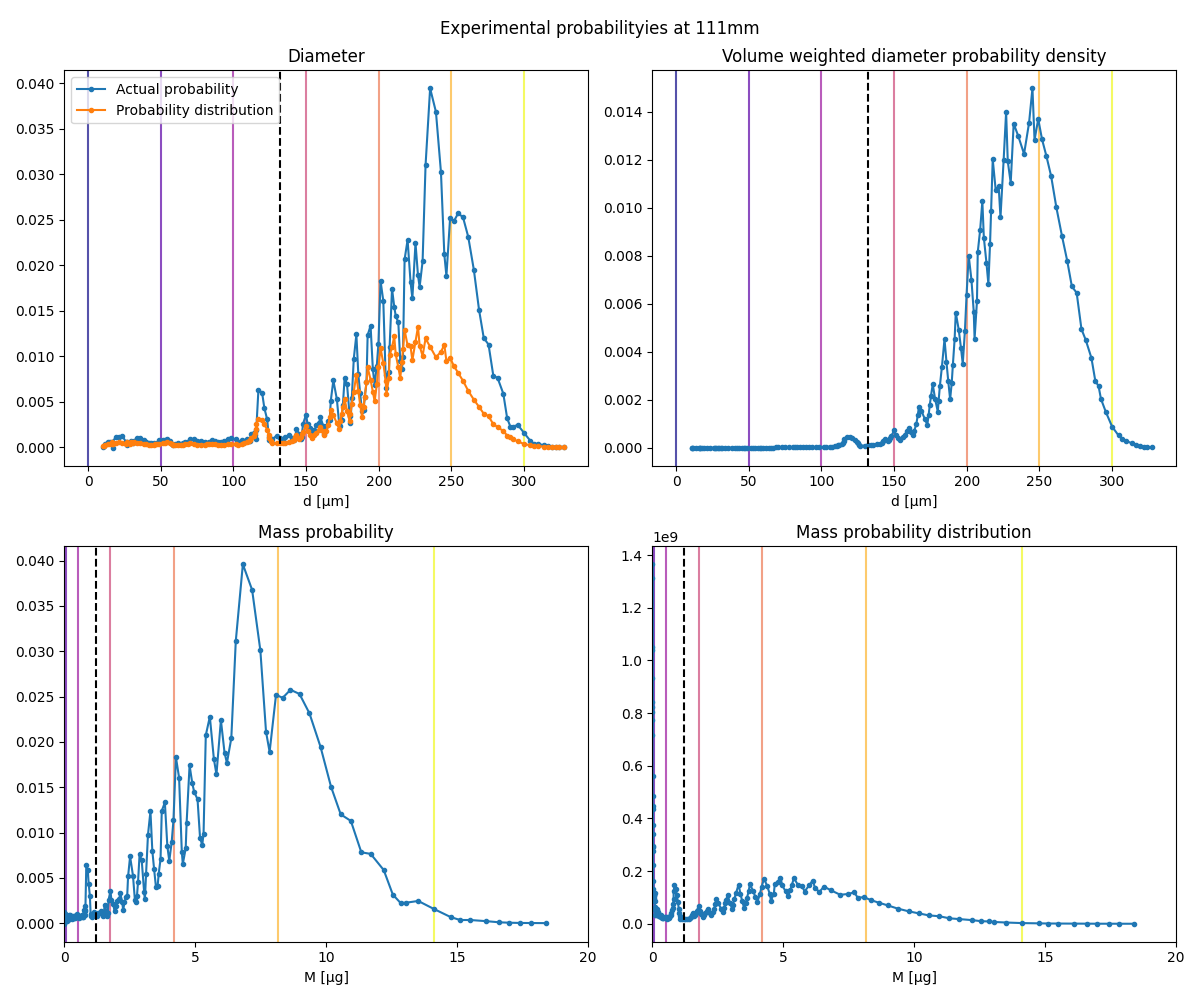

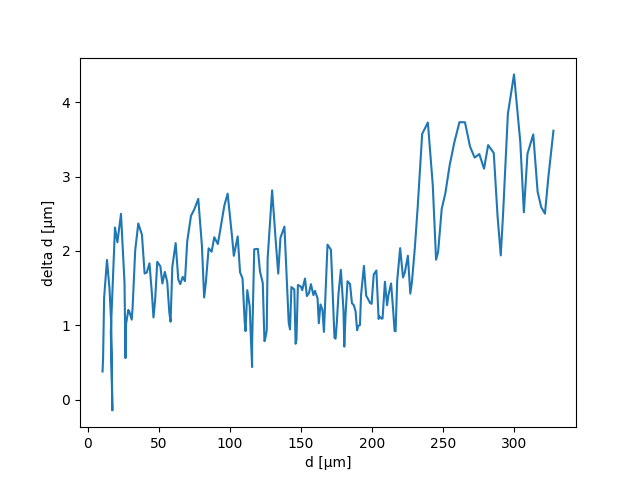

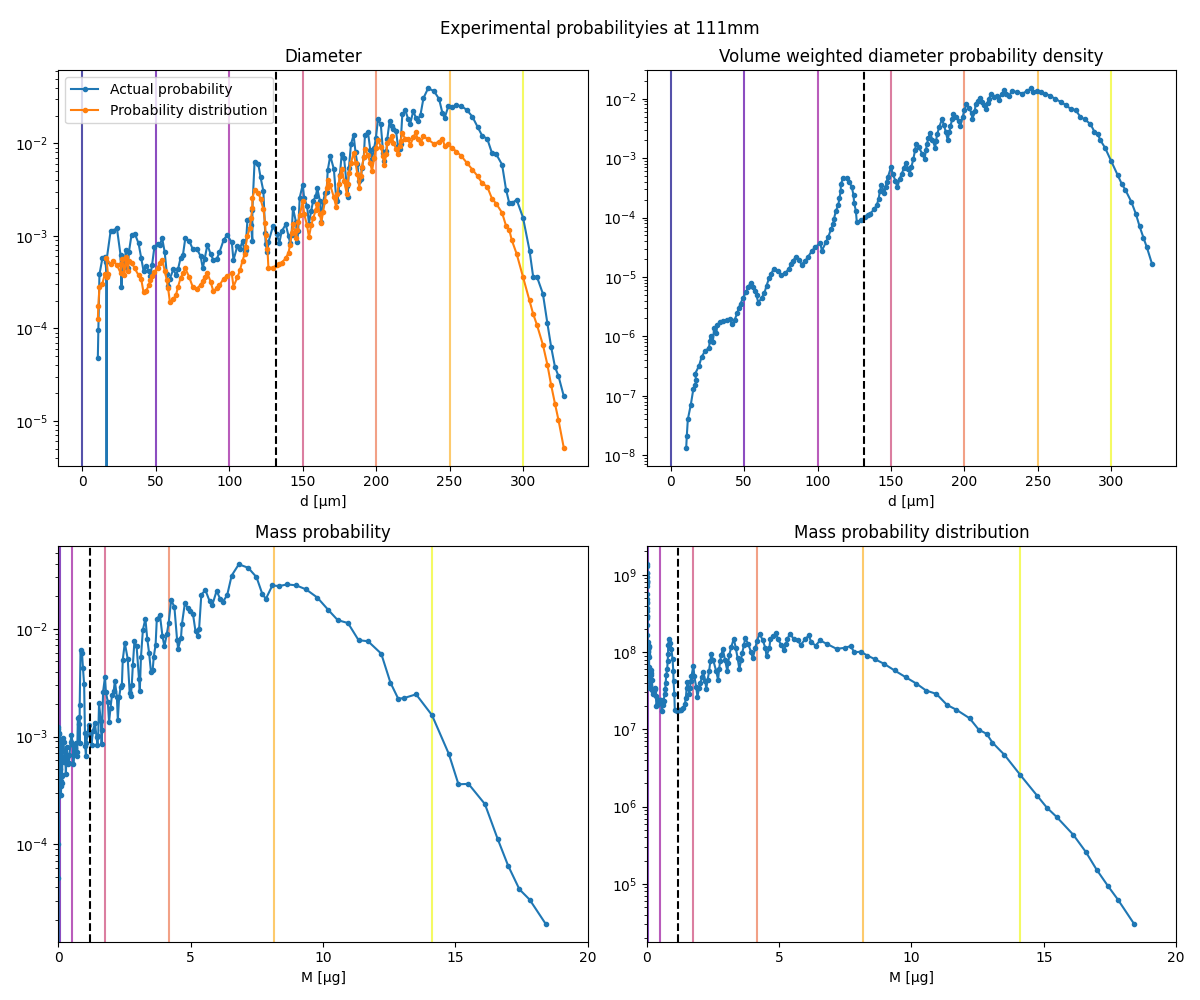

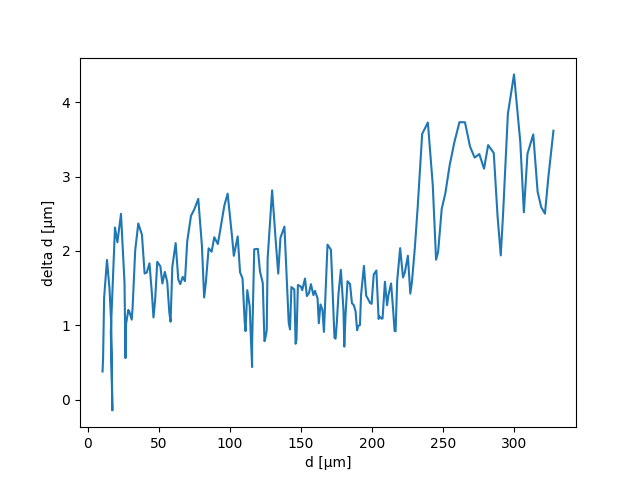

In [10]:
import matplotlib as mpl

def plotDiameterComparisons(to_plot = exp_111mm,log = False):
    fig, axs = plt.subplots(2, 2, figsize = (12, 10))
    ((ax0, ax1), (ax2, ax3))  = axs 
    fig.suptitle("Experimental probabilityies at 111mm")
    
    
    diameters = [i for i in range(0, 301, 50)]
    n_lines = len(diameters)
    cmap = mpl.colormaps['plasma']

    # Take colors at regular intervals spanning the colormap.
    colors = cmap(np.linspace(0, 1, n_lines))
    
    for i in axs:
        for j in i:
            for i_d,d in enumerate(diameters):
                if j == ax2 or j == ax3:
                    j.axvline(x = massSphere(d/2*1e-6)*1e9, color = colors[i_d], alpha = 0.7)
                else: j.axvline(x = d,                      color = colors[i_d], alpha = 0.7)
    # ax0.plot(exp_initmm.d_prob_dist_bin_centers         , exp_initmm.d_prob_dist)
    # ax1.plot(exp_initmm.d_prob_weighted_dist_bin_centers, exp_initmm.d_vol_weighted_ptob_dist)
    print("area under actual diameter prob =", np.trapezoid( to_plot.d_actual_probability,     to_plot.d_prob_dist_bin_centers ))
    print("area under diameter prob dist   =", np.trapezoid( to_plot.d_prob_density         ,     to_plot.d_prob_dist_bin_centers ))
    print("area under m actual prob        =", np.trapezoid( to_plot.m_actual_probability,     to_plot.m_prob_dist_bin_centers))
    print("area under m distribution       =", np.trapezoid( to_plot.m_prob_density,              to_plot.m_prob_dist_bin_centers))
    print("area under d prob*volume        =", np.trapezoid( to_plot.d_vol_weighted_ptob_dist, to_plot.d_prob_weighted_dist_bin_centers))
    ax0.plot(to_plot.d_prob_dist_bin_centers*1e6           , to_plot.d_actual_probability         , marker = 'o', markersize = 3, label = "Actual probability")
    ax0.plot(to_plot.d_prob_dist_bin_centers*1e6           , to_plot.d_prob_density*1e-6             , marker = 'o', markersize = 3, label = "Probability distribution")
    ax1.plot(to_plot.d_prob_weighted_dist_bin_centers*1e6  , to_plot.d_vol_weighted_ptob_dist*1e-6, marker = 'o', markersize = 3)
    ax2.plot(to_plot.m_prob_dist_bin_centers*1e9           , to_plot.m_actual_probability         , marker = 'o', markersize = 3)
    ax3.plot(to_plot.m_prob_dist_bin_centers*1e9         ,   to_plot.m_prob_density                  , marker = 'o', markersize = 3)
    # ax2.plot(to_plot.m_prob_dist_bin_centers*1e9         ,   to_plot.m_prob_dist/319233828622.42224)
    # print(np.mean(to_plot.m_prob_dist/to_plot.m_actual_probability))
    for tup_ax in axs:
        for ax in tup_ax: 
            if ax == ax2 or ax == ax3:
                ax.axvline(x = 12e-1, color = "k", linestyle = "--")
            else: 
                ax.axvline(x = massToRadius(12e-1*1e-9)*2*1e6, color = "k", linestyle = "--")
                
    if log: 
        ax0.set_yscale('log')
        ax1.set_yscale('log')
        ax2.set_yscale('log')
        ax3.set_yscale('log')
    ax0.legend()
    ax0.set_title("Diameter")
    ax1.set_title("Volume weighted diameter probability density")
    ax2.set_title("Mass probability")
    ax3.set_title("Mass probability distribution")
    ax0.set_xlabel("d [µm]")
    ax1.set_xlabel("d [µm]")
    ax2.set_xlabel("M [µg]")
    ax3.set_xlabel("M [µg]")
    ax2.set_xlim([0, 20])
    ax2.set_xticks([i for i in range(0, 21, 5)])
    ax3.set_xlim([0, 20])
    ax3.set_xticks([i for i in range(0, 21, 5)])
    plt.tight_layout()
    plt.savefig(figure_dir+str_dia+f"quadro_comp_exp_log{log}.pdf")
    
    plt.figure()
    plt.plot(to_plot.d*1e6, to_plot.dd_bin_widths*1e6)
    plt.xlabel('d [µm]')
    plt.ylabel('delta d [µm]')
plotDiameterComparisons()
plotDiameterComparisons(log=True)



area under actual diameter prob = 2.1434637132315287e-06
area under diameter prob dist   = 0.9999999999999998
area under m actual prob        = 1.7743245598119449e-10
area under m distribution       = 1.0004912892775144
area under d prob*volume        = 0.9957308835909306
area under actual diameter prob = 2.1434637132315287e-06
area under diameter prob dist   = 0.9999999999999998
area under m actual prob        = 1.7743245598119449e-10
area under m distribution       = 1.0004912892775144
area under d prob*volume        = 0.9957308835909306


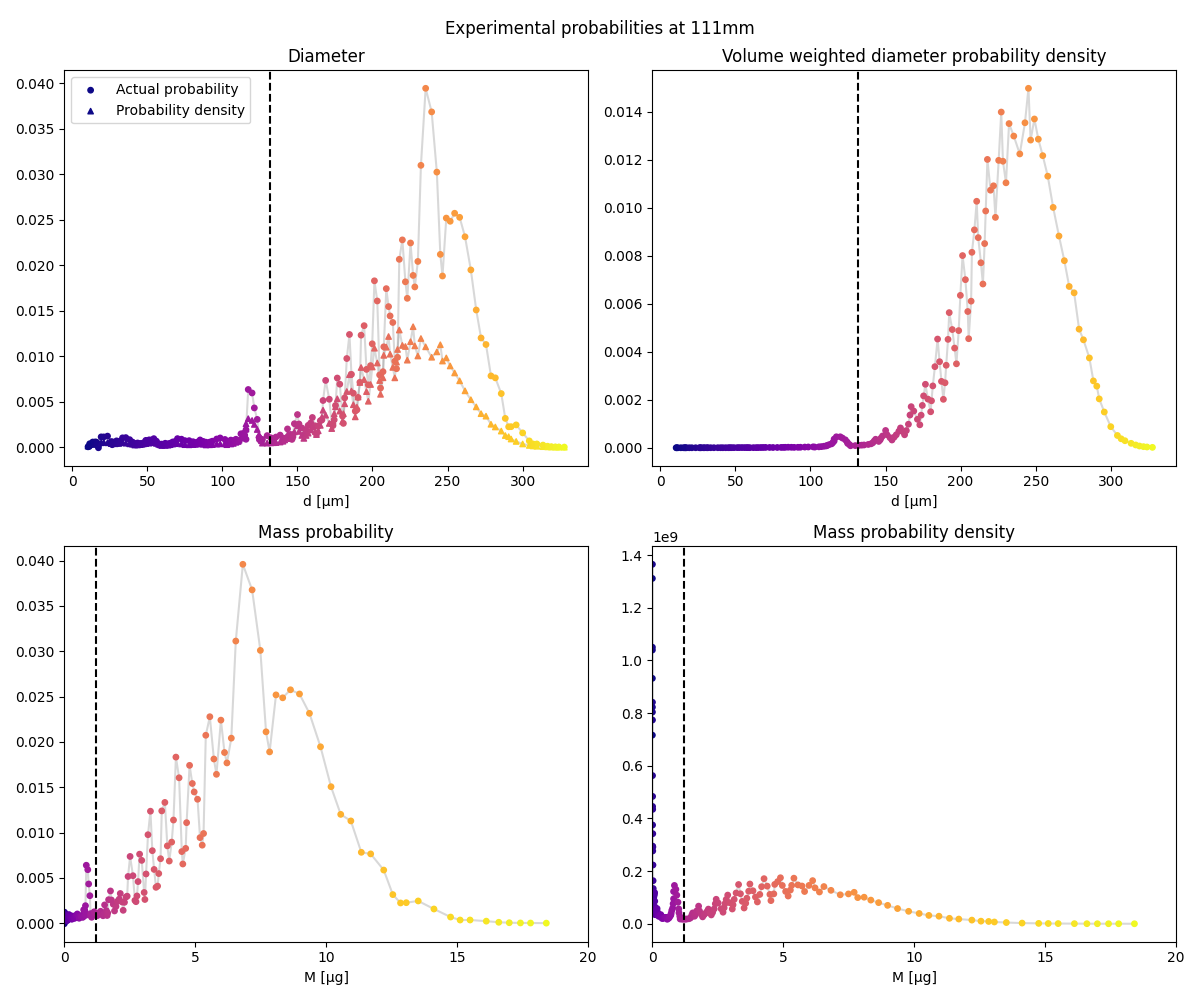

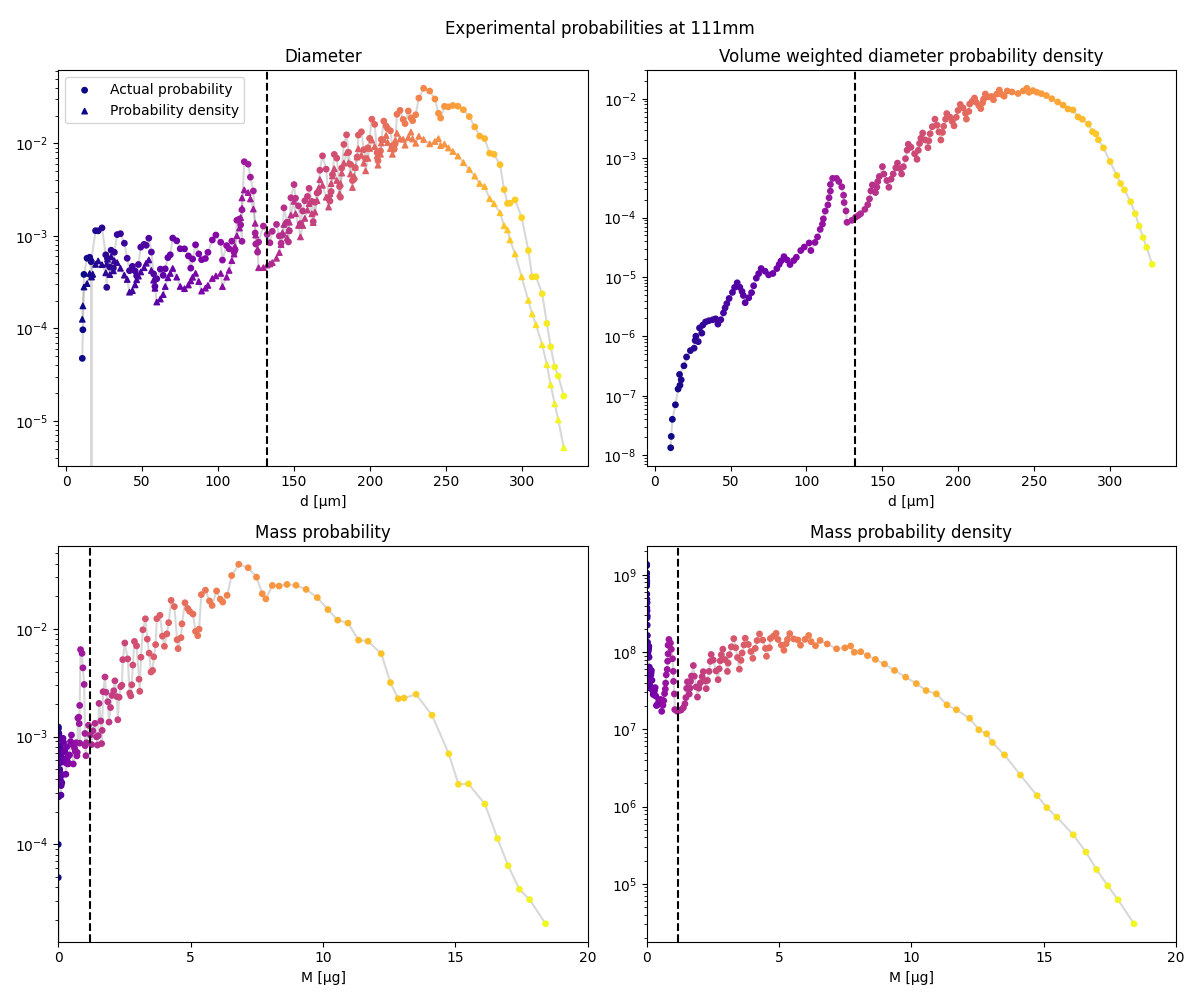

In [11]:
def plotDiameterComparisonsColors(to_plot=exp_111mm, log=False):
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    ((ax0, ax1), (ax2, ax3)) = axs 
    fig.suptitle("Experimental probabilities at 111mm")
    
    print("area under actual diameter prob =", np.trapezoid(to_plot.d_actual_probability, to_plot.d_prob_dist_bin_centers))
    print("area under diameter prob dist   =", np.trapezoid(to_plot.d_prob_density, to_plot.d_prob_dist_bin_centers))
    print("area under m actual prob        =", np.trapezoid(to_plot.m_actual_probability, to_plot.m_prob_dist_bin_centers))
    print("area under m distribution       =", np.trapezoid(to_plot.m_prob_density, to_plot.m_prob_dist_bin_centers))
    print("area under d prob*volume        =", np.trapezoid(to_plot.d_vol_weighted_ptob_dist, to_plot.d_prob_weighted_dist_bin_centers))
    
    cmap = 'plasma'
    marker_area = 15 

    x0 = to_plot.d_prob_dist_bin_centers * 1e6
    ax0.plot(x0, to_plot.d_actual_probability, color='gray', alpha=0.3, zorder=1) 
    ax0.plot(x0, to_plot.d_prob_density * 1e-6  , color='gray', alpha=0.3, zorder=1)
    sc0_1 = ax0.scatter(x0, to_plot.d_actual_probability, c=x0, cmap=cmap, s=marker_area, zorder=2               , label="Actual probability")
    sc0_2 = ax0.scatter(x0, to_plot.d_prob_density * 1e-6  , c=x0, cmap=cmap, s=marker_area, zorder=2, marker='^', label="Probability density")
    # fig.colorbar(sc0_1, ax=ax0, label="d [µm]") # Add colorbar to this axis

    x1 = to_plot.d_prob_weighted_dist_bin_centers * 1e6
    ax1.plot(         x1, to_plot.d_vol_weighted_ptob_dist * 1e-6, color='gray', alpha=0.3       , zorder=1)
    sc1 = ax1.scatter(x1, to_plot.d_vol_weighted_ptob_dist * 1e-6, c=x0, cmap=cmap, s=marker_area, zorder=2)
    # fig.colorbar(sc1, ax=ax1, label="d [µm]")

    x2 = to_plot.m_prob_dist_bin_centers * 1e9
    ax2.plot(         x2, to_plot.m_actual_probability, color='gray', alpha=0.3       , zorder=1)
    sc2 = ax2.scatter(x2, to_plot.m_actual_probability, c=x0, cmap=cmap, s=marker_area, zorder=2)
    # fig.colorbar(sc2, ax=ax2, label="d [µm]")

    x3 = to_plot.m_prob_dist_bin_centers * 1e9
    ax3.plot(         x3, to_plot.m_prob_density, color='gray', alpha=0.3, zorder=1)
    sc3 = ax3.scatter(x3, to_plot.m_prob_density, c=x0, cmap=cmap, s=marker_area, zorder=2)
    # fig.colorbar(sc3, ax=ax3, label="d [µm]")

    for tup_ax in axs:
        for ax in tup_ax: 
            if ax == ax2 or ax == ax3:
                ax.axvline(x=12e-1, color="k", linestyle="--")
            else: 
                ax.axvline(x=massToRadius(12e-1*1e-9) * 2 * 1e6, color="k", linestyle="--")
                
    if log: 
        for ax in [ax0, ax1, ax2, ax3]:
            ax.set_yscale('log')
            
    ax0.legend()
    ax0.set_title("Diameter")
    ax1.set_title("Volume weighted diameter probability density")
    ax2.set_title("Mass probability")
    ax3.set_title("Mass probability density")
    
    ax0.set_xlabel("d [µm]")
    ax1.set_xlabel("d [µm]")
    ax2.set_xlabel("M [µg]")
    ax3.set_xlabel("M [µg]") 
    
    # TODO add gamma and frichebourg fit 
    ax2.set_xlim([0, 20])
    ax2.set_xticks([i for i in range(0, 21, 5)])
    ax3.set_xlim([0, 20])
    ax3.set_xticks([i for i in range(0, 21, 5)])
    
    plt.tight_layout()
    plt.savefig(figure_dir +str_dia+ f"quadro_comp_exp_colors_log{log}.pdf")
plotDiameterComparisonsColors()
plotDiameterComparisonsColors(log=True)

In [23]:
# CA_simu          = MyProbs(getAllCAData(exclude_folders= {'OutCstm', "OutTenThou", 'Out1', 'Out2', 'tmp', "OutMonet"}, base_dir=Path("/home/erdi/Uni/LCGAStage/1DLatticeGaz")), label = "CA simu 111mm")
# CA_simu_monet    = MyProbs(getAllCAData(get_from_dir="/home/erdi/Uni/LCGAStage/1DLatticeGaz/OutMonet"), label = "CA simu monet 111mm")
# lag_simu_dt1e1   = MyProbs(label = "Lag 111mm dt1e-1µs",                      diameters = 1e-6*2*np.loadtxt("/home/erdi/Uni/LCGAStage/LaminarGravityJet/Code/Outdt1e1/111mm_rad_dt1e-7_no_acc.dat", delimiter=' '))
# lag_simu_dt1e2   = MyProbs(label = "Lag 111mm dt1e-2µs",                      diameters = 1e-6*2*np.loadtxt("/home/erdi/Uni/LCGAStage/LaminarGravityJet/Code/Outdt1e2/111mm_rad_dt1e-7_no_acc.dat", delimiter=' '))
# lag_simu_dt1e8   = MyProbs(label = "Lag 111mm dt1e-8s" ,                      diameters =      2*np.loadtxt("/home/erdi/Uni/LCGAStage/LaminarGravityJet/Code/OutMisc/acc_111mm_rad.dat"           , delimiter=' '))
# lag_simu_dt1e8_2 = MyProbs(label = "Lag 111mm dt1e-8s other" ,                diameters =      2*np.loadtxt("/home/erdi/Uni/LCGAStage/LaminarGravityJet/DT1e8/AccelerationReducedCd/111mm_rad_dt1e-8_Cdreduced.dat"           , delimiter=' '))
# latest_simu      = MyProbs(label = "latest 111mm dt1e-2µs"       ,            diameters = 1e-6*2*getDataFromFolder(get_from_dir="Code/OldOut/Out"))
# lag_simu_dt1     = MyProbs(label = "Lag 111mm dt=0.1µs other"    ,            diameters = 1e-6*2*getDataFromFolder(get_from_dir="Code/OldOut/Out1"))
# lag_simu_dt01    = MyProbs(label = "Lag 111mm dt=0.01µs other"   ,            diameters = 1e-6*2*getDataFromFolder(get_from_dir="Code/OldOut/Out01"))
# lag_simu_dt001   = MyProbs(label = "Lag 111mm dt=0.001µs other"  ,            diameters = 1e-6*2*getDataFromFolder(get_from_dir="Code/OldOut/Out001"))
# lag_simu_dt0001  = MyProbs(label = "Lag 111mm dt=0.0001µs other" ,            diameters = 1e-6*2*getDataFromFolder(get_from_dir="Code/OldOut/Out0001Long"))
# frecx2           = MyProbs(label = "Frequency modified x2 111mm dt1e-2µs"   , diameters = 1e-6*2*getDataFromFolder(get_from_dir="Code/OldOut/OutNewF"))
# frec01           = MyProbs(label = "F=01 µs 111mm dt1e-2µs"                 , diameters = 1e-6*2*getDataFromFolder(get_from_dir="Code/OldOut/OutF01"))
# frec1            = MyProbs(label = "F=1  µs 111mm dt1e-2µs"                 , diameters = 1e-6*2*getDataFromFolder(get_from_dir="Code/OldOut/OutF1"))
# frec5            = MyProbs(label = "F=5  µs 111mm dt1e-2µs"                 , diameters = 1e-6*2*getDataFromFolder(get_from_dir="Code/OldOut/OutF5"))
old_clean_lagrangian_jet_dir = "/home/erdi/Uni/LCGAStage/CleanLagrangianLaminarJet/"
frec10               = MyProbs(label = "F=10 µs 111mm dt1e-2µs"                                               , diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OldOut/OutF10"))
frec20               = MyProbs(label = "F=20 µs 111mm dt1e-2µs"                                               , diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OldOut/OutF20"))
frec28               = MyProbs(label = "F=28 µs 111mm dt1e-4µs"                                               , diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OldOut/OutF28_0001"))
frec30               = MyProbs(label = "F=30 µs 111mm dt1e-2µs"                                               , diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OldOut/OutF30Long"))
frec35               = MyProbs(label = "F=35 µs 111mm dt1e-2µs"                                               , diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OldOut/OutF35"))
frec40               = MyProbs(label = "F=40 µs 111mm dt1e-2µs"                                               , diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OldOut/OutF40"))
frec50               = MyProbs(label = "F=50 µs 111mm dt1e-2µs"                                               , diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OldOut/OutF50"))
frec100              = MyProbs(label = "F=100µs 111mm dt1e-2µs"                                               , diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OldOut/OutF100"))
redo11mm             = MyProbs(label = "F=30 µs real 11mm dt1e-2µs"                                           , diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/Out11")                      , velocities= getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/Out11"         , file_name_regex="velocity*.dat"))
redo22mm             = MyProbs(label = "F=30 µs real 22mm dt1e-2µs"                                           , diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/Out22")                      , velocities= getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/Out22"         , file_name_regex="velocity*.dat"))
redo34mm             = MyProbs(label = "F=30 µs real 34mm dt1e-2µs"                                           , diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/Out34")                      , velocities= getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/Out34"         , file_name_regex="velocity*.dat"))
redo58mm             = MyProbs(label = "F=30 µs real 58mm dt1e-2µs"                                           , diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/Out58")                      , velocities= getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/Out58"         , file_name_regex="velocity*.dat"))
redo111mm            = MyProbs(label = "F=30 µs real 111mm dt1e-2µs"                                          , diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/Out111")                     , velocities= getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/Out111"        , file_name_regex="velocity*.dat"))
redo111mm_acc        = MyProbs(label = "F=30 µs real 111mm dt1e-2µs acc"   ,n_bins=100                        , diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OutF30X111Grav")             , velocities= getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OutF30X111Grav", file_name_regex="velocity*.dat"))
f15_30_111mm         = MyProbs(label = "F=15-30 µs real 111mm dt1e-2µs"                                       , diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OutF15_30X111")              , velocities= getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OutF15_30X111" , file_name_regex="velocity*.dat"))
redo111mm            = MyProbs(label = "F=29.25 µs real 111mm dt1e-2µs"                                       , diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OutF2925X111")               , velocities= getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OutF2925X111"  , file_name_regex="velocity*.dat"))
redo12mm             = MyProbs(label = "F=30 µs real 12mm dt1e-2µs"                                           , diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/Out12")                      , velocities= getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/Out12"         , file_name_regex="velocity*.dat"))
energy001_111mm      = MyProbs(label = "F=29.25 µs energy reduction 0.01 111mm dt1e-2µs"                      , diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OutEnergy001")               , velocities= getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OutEnergy001"  , file_name_regex="velocity*.dat"))
energy002_111mm      = MyProbs(label = "F=29.25 µs energy reduction 0.02 111mm dt1e-2µs"                      , diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OutEnergy002")               , velocities= getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OutEnergy002"  , file_name_regex="velocity*.dat"))
energy005_111mm      = MyProbs(label = "F=29.25 µs energy reduction 0.05 111mm dt1e-2µs"                      , diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OutEnergy005")               , velocities= getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OutEnergy005"  , file_name_regex="velocity*.dat"))
energy01_111mm       = MyProbs(label = "F=29.25 µs energy reduction 0.1 111mm dt1e-2µs"                       , diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OutEnergy01")                , velocities= getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OutEnergy01"   , file_name_regex="velocity*.dat"))
We1energy002_111mm   = MyProbs(label = "F=29.25 µs energy reduction 0.02 We < 1 bounce back 111mm dt1e-2µs"   , diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OutEnergy002We1BounceBack")  , velocities= getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OutEnergy002We1BounceBack"  , file_name_regex="velocity*.dat"))
We01energy002_111mm  = MyProbs(label = "F=29.25 µs energy reduction 0.02 We < 0.1 bounce back 111mm dt1e-2µs" , diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OutEnergy002We01BounceBack") , velocities= getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OutEnergy002We01BounceBack" , file_name_regex="velocity*.dat"))
We01energy0_111mm    = MyProbs(label = "F=29.25 µs energy reduction 0 We < 0.1 bounce back 111mm dt1e-2µs"    , diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OutEnergy0We01BounceBack")   , velocities= getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OutEnergy0We01BounceBack"   , file_name_regex="velocity*.dat"))
We001energy002_111mm = MyProbs(label = "F=29.25 µs energy reduction 0.02 We < 0.01 bounce back 111mm dt1e-2µs", diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OutEnergy002We001BounceBack"), velocities= getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OutEnergy002We001BounceBack", file_name_regex="velocity*.dat"))
We01energy001_111mm  = MyProbs(label = "F=29.25 µs energy reduction 0.01 We < 0.1 bounce back 111mm dt1e-2µs" , diameters = 1e-6*2*getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OutEnergy001We01BounceBack") , velocities= getDataFromFolder(get_from_dir=old_clean_lagrangian_jet_dir+"Code/OutEnergy001We01BounceBack" , file_name_regex="velocity*.dat"))
ColDist2x111mm       = MyProbs(label = "F=29.25 µs 2xColDist 111mm dt1e-2µs"                                  , diameters = 1e-6*2*getDataFromFolder(get_from_dir="/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Data/Out29_25_111mm_2xColDist"), velocities= getDataFromFolder(get_from_dir="/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/Data/Out29_25_111mm_2xColDist", file_name_regex="velocity*.dat"), n_bins=300)


F=10 µs 111mm dt1e-2µs
area under diameter prob dist   = 0.99996
area under m distribution       = 0.9951150000000001
area under d prob*volume        = 0.9999487154115421
F=20 µs 111mm dt1e-2µs
area under diameter prob dist   = 0.9999900000000002
area under m distribution       = 0.9964099999999999
area under d prob*volume        = 0.9999726085862976
F=28 µs 111mm dt1e-4µs
area under diameter prob dist   = 0.9998749999999998
area under m distribution       = 0.9960000000000001
area under d prob*volume        = 0.9996711720246194
F=30 µs 111mm dt1e-2µs
area under diameter prob dist   = 0.9999984210526316
area under m distribution       = 0.9958784210526315
area under d prob*volume        = 0.9999983916622693
F=35 µs 111mm dt1e-2µs
area under diameter prob dist   = 0.9999900000000002
area under m distribution       = 0.9957199999999999
area under d prob*volume        = 0.9999731190543185
F=40 µs 111mm dt1e-2µs
area under diameter prob dist   = 0.9999849999999999
area under m distribution

In [13]:

new_fold = "/home/erdi/Uni/LCGAStage/Jets/LagrangianJet/"
ColDist5x111mm              = MyProbs(label = "F=29.25 µs 5xColDist 111mm dt1e-2µs"                                               , diameters = 1e-6*2*getDataFromFolder(get_from_dir=new_fold+"Data/Out29_25_111ColMult5x"), velocities= getDataFromFolder(get_from_dir=new_fold+"Data/Out29_25_111ColMult5x", file_name_regex="velocity*.dat"), n_bins=300)
uniform_dist_vel_11mm       = MyProbs(label = "F=29.25 µs uniform vel 9-11m/s 11mm "  , color = "blue",linestyle = ":", diameters = 1e-6*2*getDataFromFolder(get_from_dir=new_fold+"Data/Out29_25_11mmUniformDia100_165um_and_Vel9_11") , velocities= getDataFromFolder(get_from_dir=new_fold+"Data/Out29_25_11mmUniformDia100_165um_and_Vel9_11", file_name_regex="velocity*.dat"), n_bins=300)
uniform_dist_vel_111mm      = MyProbs(label = "F=29.25 µs uniform vel 9-11m/s 111mm"  , color = "blue"                                   , diameters = 1e-6*2*getDataFromFolder(get_from_dir=new_fold+"Data/Out29_25_111mmUniformDia100_165um_and_Vel9_11"), velocities= getDataFromFolder(get_from_dir=new_fold+"Data/Out29_25_111mmUniformDia100_165um_and_Vel9_11", file_name_regex="velocity*.dat"), n_bins=300)
uniform_dist_vel_dia_11mm   = MyProbs(label = "F=29.25 µs uniform vel 9-11m/s 11mm "  , color = "red", linestyle = ":", diameters = 1e-6*2*getDataFromFolder(get_from_dir=new_fold+"Data/Out29_25_11mmUniformVel9_11")                  , velocities= getDataFromFolder(get_from_dir=new_fold+"Data/Out29_25_11mmUniformVel9_11", file_name_regex="velocity*.dat"), n_bins=300)
uniform_dist_vel_dia_111mm  = MyProbs(label = "F=29.25 µs uniform vel 9-11m/s 111mm"  , color = "red", diameters = 1e-6*2*getDataFromFolder(get_from_dir=new_fold+"Data/Out29_25_111mmUniformVel9_11")                 , velocities= getDataFromFolder(get_from_dir=new_fold+"Data/Out29_25_111mmUniformVel9_11", file_name_regex="velocity*.dat"), n_bins=300)
# We01energy0_111mm    = MyProbs(label = "F=29.25 µs energy reduction 0 We < 0.1 bounce back 111mm dt1e-2µs" , diameters = 1e-6*2*getDataFromFolder(get_from_dir="Code/OutEnergy0We01BounceBack"), velocities= getDataFromFolder(get_from_dir="Code/OutEnergy0We01BounceBack", file_name_regex="velocity*.dat"))

# redo11mm         = MyProbs(label = "F=30 µs real 11mm dt1e-2µs"     , diameters = 1e-6*2*getDataFromFolder(get_from_dir="Code/Out11")  , velocities= getDataFromFolder(get_from_dir="Code/Out0", file_name_regex="velocity*.dat"))


F=29.25 µs 5xColDist 111mm dt1e-2µs
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999979999999999
area under m distribution       = 0.9988285000000001
area under d prob*volume        = 0.9999958961329642
F=29.25 µs uniform vel 9-11m/s 11mm 
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9966554999999999
area under m distribution       = 0.9959184999999999
area under d prob*volume        = 0.9962989946843757


/home/erdi/Programs/PythonVenvs/GeneralPy314/lib/python3.14/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


F=29.25 µs uniform vel 9-11m/s 111mm
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9988733333333334
area under m distribution       = 0.9912849999999999
area under d prob*volume        = 0.9999219296187772
F=29.25 µs uniform vel 9-11m/s 11mm 
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999924999999998
area under m distribution       = 0.9820025
area under d prob*volume        = 0.9999974586524147
F=29.25 µs uniform vel 9-11m/s 111mm
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999900000000002
area under m distribution       = 0.995125
area under d prob*volume        = 0.9999706000505577


In [14]:
norm_time_std9_dist111mm   = MyProbs(label = "F=29.25µs std_F=9 111mm"   , color = "red", diameters = 1e-6*2*getDataFromFolder(get_from_dir=new_fold+"Data/Simus501/At111mmNormalDist/29.25_dev9_111mm_dt1e-2")                 
                                                                                        , velocities=        getDataFromFolder(get_from_dir=new_fold+"Data/Simus501/At111mmNormalDist/29.25_dev9_111mm_dt1e-2", file_name_regex="velocity*.dat"), n_bins=300)
norm_time_std12_dist111mm  = MyProbs(label = "F=29.25µs std_F=12 111mm"  , color = "red", diameters = 1e-6*2*getDataFromFolder(get_from_dir=new_fold+"Data/Simus501/At111mmNormalDist/29.25_dev12_111mm_dt1e-2")                 
                                                                                        , velocities=        getDataFromFolder(get_from_dir=new_fold+"Data/Simus501/At111mmNormalDist/29.25_dev12_111mm_dt1e-2", file_name_regex="velocity*.dat"), n_bins=300)
redo2_111mm  = MyProbs(label = "F=29.25µs 111mm"  , color = "red", diameters = 1e-6*2*getDataFromFolder(get_from_dir=new_fold+"Data/Simus501/Normal/29.25_111mm_dt1e-2")                 , velocities= getDataFromFolder(get_from_dir=new_fold+"Data/Simus501/Normal/29.25_111mm_dt1e-2", file_name_regex="velocity*.dat"), n_bins=300)
norm_time_std001_dist111mm  = MyProbs(label = "F=29.25µs std_F=0.01 111mm"  , color = "red", diameters = 1e-6*2*getDataFromFolder(get_from_dir=new_fold+"Data/Simus501/NurmalDistDropTime/29.25_dev0.01_111mm_dt1e-2")                 , velocities= getDataFromFolder(get_from_dir=new_fold+"Data/Simus501/NurmalDistDropTime/29.25_dev0.01_111mm_dt1e-2", file_name_regex="velocity*.dat"), n_bins=300)


F=29.25µs std_F=9 111mm
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999965
area under m distribution       = 0.9954205
area under d prob*volume        = 0.9999937994563536
F=29.25µs std_F=12 111mm
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999985
area under m distribution       = 0.9954654999999999
area under d prob*volume        = 0.9999964446563934
F=29.25µs 111mm
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999975
area under m distribution       = 0.9955125
area under d prob*volume        = 0.9999968326362931
F=29.25µs std_F=0.01 111mm
NEED THE DIAMETERS IN METERS
area under diameter prob dist   = 0.9999349999999998
area under m distribution       = 0.99556
area under d prob*volume        = 0.9999652197416186


Text(0, 0.5, 'v')

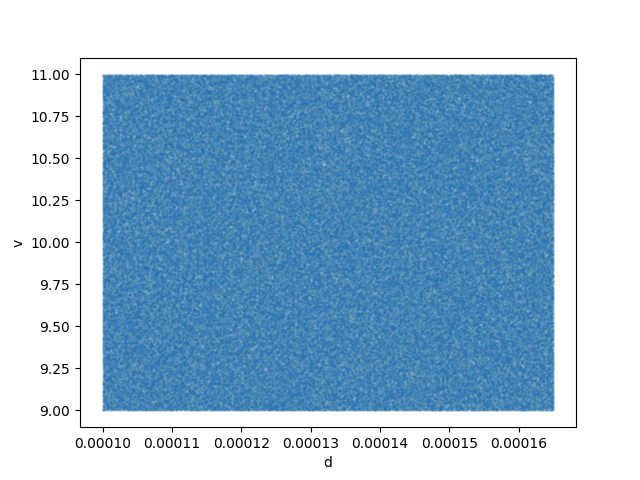

In [15]:
plt.figure()
plt.scatter(uniform_dist_vel_11mm.d, uniform_dist_vel_11mm.v, alpha = 0.1, s = 0.1)
plt.xlabel("d")
plt.ylabel("v")
# TODO fractal dimension in md space
# xm xm-2
# TODO do the historical parts villermaux and 

In [36]:
bounce_back_list = [ redo111mm, 
                     We01energy0_111mm,
                     energy001_111mm,
                    #  energy002_111mm,
                    #  energy005_111mm,
                    #  energy01_111mm,
                    # We1energy002_111mm,
                    # We01energy002_111mm,
                    #  We001energy002_111mm,
                    #  We01energy001_111mm,
                     ColDist2x111mm,
                     ColDist5x111mm
                     ]
uniform_dist_list = [uniform_dist_vel_11mm       
                    ,uniform_dist_vel_111mm      
                    ,uniform_dist_vel_dia_11mm   
                    ,uniform_dist_vel_dia_111mm ]
all_simus_111mm = bounce_back_list

NameError: name 'redo11mm' is not defined

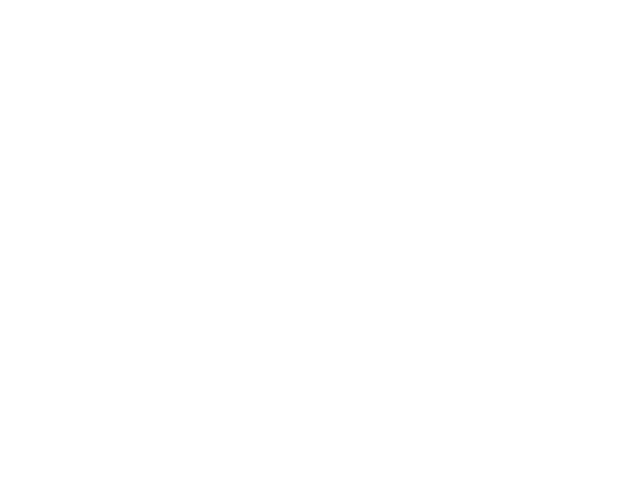

In [16]:
plt.figure()
all_redos = [ redo11mm
             ,redo22mm
             ,redo34mm
             ,redo58mm
            #  ,f15_30_111mm 
             ,redo111mm_acc,
             redo111mm,
            ]
L = [11, 22,34,58,111, 111]
for i, r in enumerate(all_redos):
    avg_mass = np.mean(r.m)
    plt.scatter(L[i], avg_mass*1e9, label=r.label, s = 60)
plt.xlabel("$L [mm]$")
plt.ylabel("Average Mass [µg]")
x = np.linspace(10, 120, 100)
# plt.plot(x, x/25)
plt.plot(x, (x/12)**(2/3), color = "k")

# x_start = 12 
# x_end   = 20 
# y_start = (x_start/12)**(2/3)
# y_end   = (x_end/12)**(2/3)  
# plt.plot([x_start, x_end], [y_start, y_start], color="k", lw=1) # Horizontal
# plt.plot([x_end, x_end], [y_start, y_end], color="k", lw=1)     # Vertical
# plt.text(np.sqrt(x_start * x_end), y_start * 0.92, "3", ha='center', va='top', fontsize=10)
# plt.text(x_end * 1.05, np.sqrt(y_start * y_end), "2", ha='left', va='center', fontsize=10)

ax = plt.gca() # Get current axes
axins = ax.inset_axes([0.4, 0.30, 0.15, 0.15]) 
axins.plot([0, 3], [0, 0], color='black', lw=1.5)  # Run
axins.plot([3, 3], [0, 2], color='black', lw=1.5)  # Rise
axins.plot([0, 3], [0, 2], color='black', lw=1.5)  # Hypotenuse
axins.text(1.5, -0.3, "3", ha='center', va='top', fontsize=11)
axins.text(3.3, 1.0, "2", ha='left', va='center', fontsize=11)
axins.set_xlim(-0.5, 4.5)
axins.set_ylim(-1, 3)
axins.axis('off')

plt.xscale('log')
plt.yscale('log')
plt.legend()
# plt.grid()
plt.savefig(figure_dir+"mass_avgs.pdf")
# plt.xlim([1e-3, 2e-2])
# plt.ylim([1, 10])

NameError: name 'redo11mm' is not defined

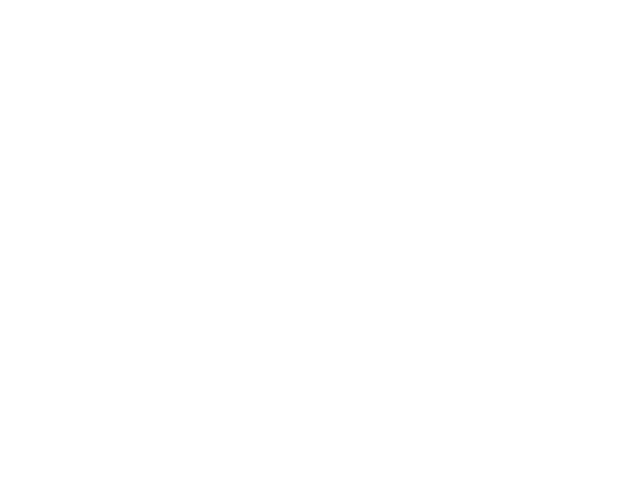

In [17]:
plt.figure()
plt.scatter(redo11mm.v_satelite_prob_dist_bin_centers, redo11mm.v_satelite_prob_density,alpha = 0.75, label = "satelite droplets")
plt.scatter(redo11mm.v_main_prob_dist_bin_centers,     redo11mm.v_main_prob_density    ,alpha = 0.75, label = "main droplets")
plt.yscale('log')
plt.xlabel("$v[m/s]$")
plt.ylabel("pdf")
plt.legend()
plt.xlim([7.75, 12.5])
plt.savefig(figure_dir+"my_init_vel_dist.pdf")

plt.figure()
idx_sat  = redo11mm.d_prob_dist_bin_centers < 85e-6
idx_main = redo11mm.d_prob_dist_bin_centers > 85e-6
plt.scatter(redo11mm.d_prob_dist_bin_centers[idx_sat] *1e6, redo11mm.d_prob_density[idx_sat]*1e-6,alpha = 0.75, label = "satelite droplets")
plt.scatter(redo11mm.d_prob_dist_bin_centers[idx_main]*1e6, redo11mm.d_prob_density[idx_main]*1e-6,alpha = 0.75, label = "main droplets")
plt.yscale('log')
plt.xlabel("$d[µm]$")
plt.ylabel("pdf")
plt.legend()
plt.savefig(figure_dir+"my_init_dia_dist.pdf")

plt.figure()
plt.scatter(redo12mm.v_satelite_prob_dist_bin_centers, redo12mm.v_satelite_prob_density,alpha = 0.75, label = "satelite droplets")
plt.scatter(redo12mm.v_main_prob_dist_bin_centers,     redo12mm.v_main_prob_density    ,alpha = 0.75, label = "main droplets")
plt.yscale('log')
plt.xlabel("$v[m/s]$")
plt.ylabel("pdf")
plt.legend()
plt.xlim([7.75, 12.5])
plt.savefig(figure_dir+"my_vel_at12mm.pdf")

TODO  there should be an explanation to why there is a drop in satelite drop frequanecy around 9m/s

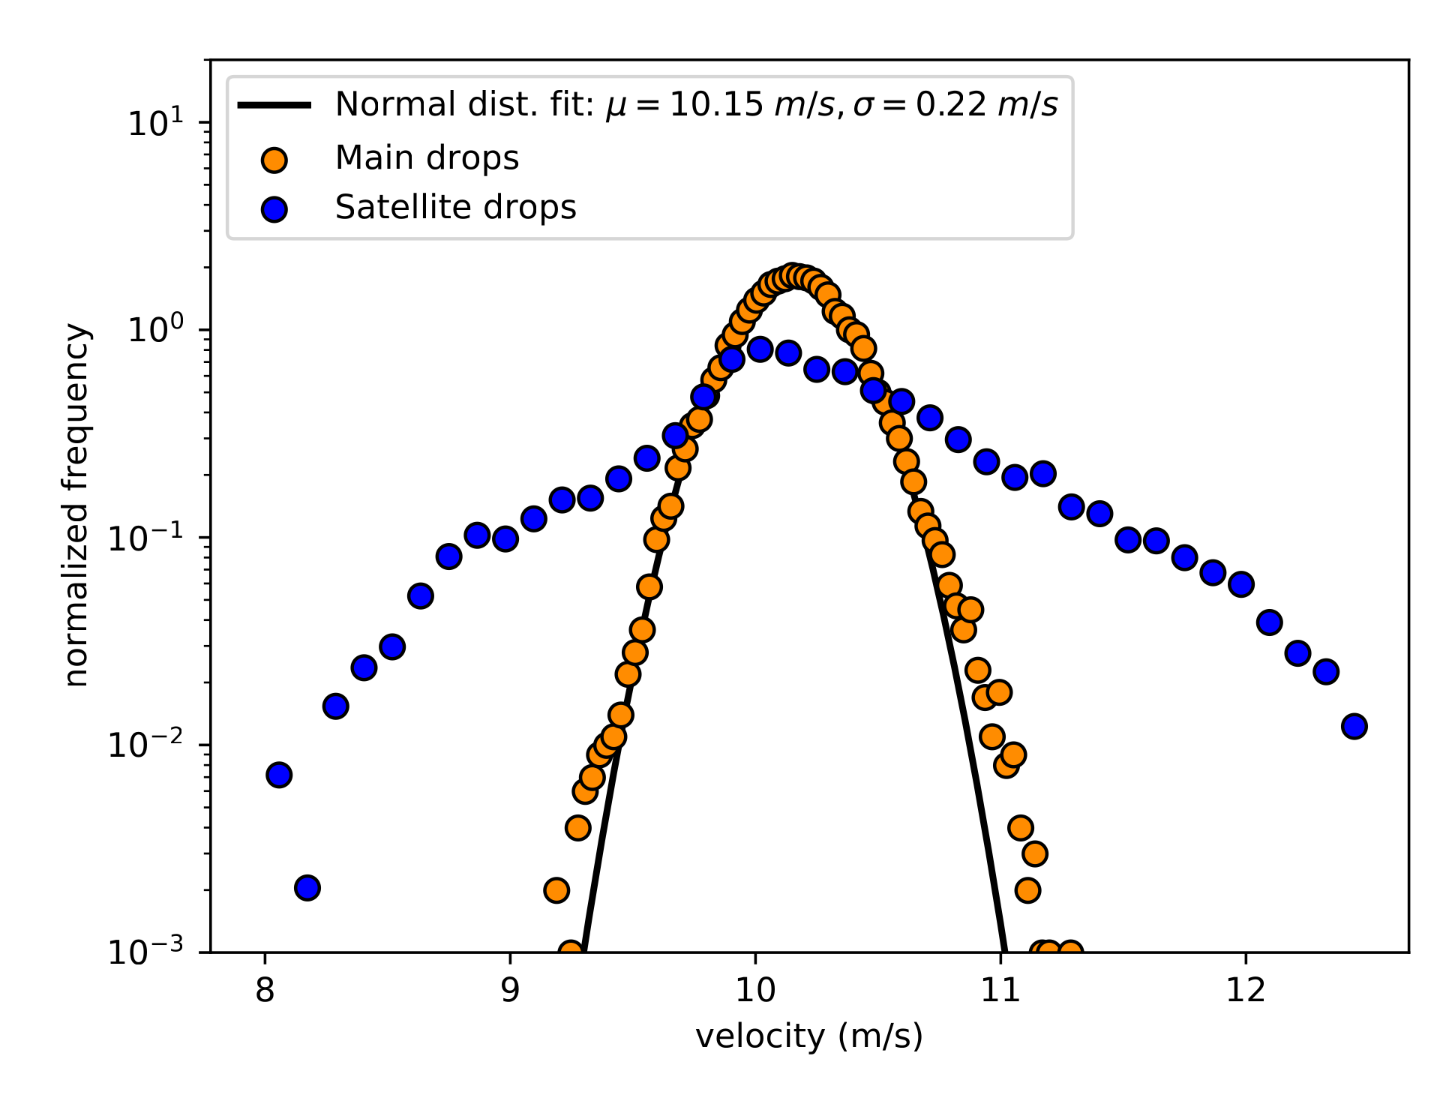

In [ ]:

all_simus_111mm = [
                #CA_simu_monet, 
                #    CA_simu,
                #    lag_simu_dt1e1, 
                #    lag_simu_dt1e2,
                  # lag_simu_dt1e8,
                  # lag_simu_dt1e8_2, 
                #    latest_simu,
                #    frecx2, 
                #    frec01,
                #    frec1 ,
                #    frec5 ,
                   frec10,
                #    frec20,
                #    frec28,
                   frec30,
                #    frec35,
                #    frec40,
                   frec50 ,
                #    frec100
                   redo111mm,
                #    redo111mm_acc,
                   redo11mm,
                #    redo12mm,
                   ]  
all_simus_111mm = bounce_back_list
# all_simus_111mm = [CA_simu]
# all_simus_111mm = [
#                     lag_simu_dt1 ,    
#                     lag_simu_dt01    ,
#                     lag_simu_dt001   ,
#                     lag_simu_dt0001  
#                     ]

In [18]:
def plotMassHistogramComparisons(list_of_probs, to_µg = 1e9, log = False):
    plt.figure()
    for p in list_of_probs:
        plt.hist(p.m*to_μg, bins = p.n_bins, label = p.label)
    if log: plt.yscale('log')
    plt.legend()
    plt.xlabel("$M$ $[µg]$")
    plt.ylabel("Number distribution")

figure_size_cstm = (6, 4)
def plotProbabilityDensityByVolumeComp(list_of_probs, log = False, lines = True, save_name = "_compared_exp_"):
    plt.figure(figsize=figure_size_cstm)
    # plt.imshow(plt.imread("/home/erdi/Uni/LCGAStage/LaminarGravityJet/Code/Figures/image.png"),
    #         extent=[0, 300, -8, -2], aspect='auto', origin='upper')#
    plt.plot(exp_11mm_init.d_prob_weighted_dist_bin_centers*1e6, 1e-6*exp_11mm_init.d_vol_weighted_ptob_dist,":k", label = exp_11mm_init.label)
    plt.plot(exp_111mm.d_prob_weighted_dist_bin_centers    *1e6, 1e-6*exp_111mm.d_vol_weighted_ptob_dist    ,"-k", label = exp_111mm.label)
    # print(np.trapezoid(exp_111mm.d_vol_weighted_ptob_dist, exp_111mm.d_prob_weighted_dist_bin_centers))
    for p in list_of_probs:
        # print(p.label)        
        if lines == True:
            plt.plot(p.d_prob_weighted_dist_bin_centers*1e6, p.d_vol_weighted_ptob_dist*1e-6, label = p.label, linestyle = p.linestyle)
        else: 
            plt.plot(p.d_prob_weighted_dist_bin_centers*1e6, p.d_vol_weighted_ptob_dist*1e-6, "o", label = p.label, markersize = 1)
        print(np.trapezoid(p.d_vol_weighted_ptob_dist, p.d_prob_weighted_dist_bin_centers))
    
    plt.legend()#loc="upper right")
    if log: plt.yscale('log')
    plt.title("Probability density by volume")
    plt.xlabel("$d$ $[µm]$")
    plt.ylabel("probability density by volume")
    plt.tight_layout()
    plt.savefig(figure_dir+save_name+f"PDF_vol_log{log}.pdf")
    
"""
def plotProbabilityDensityComp(list_of_probs, log = False, lines = True, title = "Probability density",save_name="probabilty_densities_compared_exp"):
    plt.figure(figsize=figure_size_cstm)
    # plt.imshow(plt.imread("/home/erdi/Uni/LCGAStage/LaminarGravityJet/Code/Figures/image.png"),
    #         extent=[0, 300, -8, -2], aspect='auto', origin='upper')#
    plt.plot(exp_11mm_init.d_prob_dist_bin_centers*1e6, 1e-6*exp_11mm_init.d_prob_density,":k", label = exp_11mm_init.label)
    plt.plot(exp_111mm.d_prob_dist_bin_centers    *1e6, 1e-6*exp_111mm.    d_prob_density,"-k", label = exp_111mm.label)
    # print(np.trapezoid(exp_111mm.d_vol_weighted_ptob_dist, exp_111mm.d_prob_weighted_dist_bin_centers))
    for p in list_of_probs:
        # print(p.label)        
        if lines == True:
            if p.color is not None:
                plt.plot(p.d_prob_dist_bin_centers*1e6, p.d_prob_density*1e-6, label = p.label, linestyle = p.linestyle, color = p.color)
            else :
                plt.plot(p.d_prob_dist_bin_centers*1e6, p.d_prob_density*1e-6, label = p.label, linestyle = p.linestyle)
        else: 
            plt.plot(p.d_prob_dist_bin_centers*1e6, p.d_prob_density*1e-6, "o",label = p.label)
        # print(np.trapezoid(p.d_prob_density, p.d_prob_dist_bin_centers*1e6))
    
    plt.legend()#loc="upper right")
    if log: plt.yscale('log')
    plt.title(title)
    plt.xlabel("$d$ $[µm]$")
    plt.ylabel("probability density")
    plt.savefig(figure_dir+save_name+f"log_{log}.pdf")
"""
import matplotlib.colors as mcolors

colors_b2g = ['#08306b', '#1f78b4', '#41ab5d']#, '#006d2c']
# colors_b2g = ["tab:blue", "tab:orange"]#, '#006d2c']
cmap_blue_green = mcolors.LinearSegmentedColormap.from_list("custom_b2g", colors_b2g)

colors_org = ['#7f2704', '#d94801', '#fd8d3c', '#fec44f']
cmap_orange = mcolors.LinearSegmentedColormap.from_list("custom_org", colors_org)

def plotProbabilityDensityComp(list_of_probs, log = False, lines = True, title = "Probability density",save_name="probabilty_densities_compared_exp", gradient=False, cmap = None):
    plt.figure(figsize=figure_size_cstm)
    # plt.imshow(plt.imread("/home/erdi/Uni/LCGAStage/LaminarGravityJet/Code/Figures/image.png"),
    #         extent=[0, 300, -8, -2], aspect='auto', origin='upper')#
    plt.plot(exp_11mm_init.d_prob_dist_bin_centers*1e6, 1e-6*exp_11mm_init.d_prob_density,":k", label = exp_11mm_init.label)
    plt.plot(exp_111mm.d_prob_dist_bin_centers    *1e6, 1e-6*exp_111mm.    d_prob_density,"-k", label = exp_111mm.label)
    # print(np.trapezoid(exp_111mm.d_vol_weighted_ptob_dist, exp_111mm.d_prob_weighted_dist_bin_centers))
    
    n_probs = len(list_of_probs)
    
    for i, p in enumerate(list_of_probs):
        frac = i / max(1, n_probs - 1)
        # plot_color = plt.cm.viridis(frac*0.8) if gradient else p.color
        cmap_choosen = cmap_blue_green if cmap is None else cmap 
        plot_color = cmap_choosen(frac) if gradient else p.color
        # print(p.label)        
        if lines == True:
            if plot_color is not None:
                plt.plot(p.d_prob_dist_bin_centers*1e6, p.d_prob_density*1e-6, label = p.label, linestyle = p.linestyle, color = plot_color)
            else :
                plt.plot(p.d_prob_dist_bin_centers*1e6, p.d_prob_density*1e-6, label = p.label, linestyle = p.linestyle)
        else: 
            if gradient: # Apply the gradient to the scatter dots as well
                plt.plot(p.d_prob_dist_bin_centers*1e6, p.d_prob_density*1e-6, "o", label = p.label, color = plot_color)
            else:
                plt.plot(p.d_prob_dist_bin_centers*1e6, p.d_prob_density*1e-6, "o", label = p.label)
        # print(np.trapezoid(p.d_prob_density, p.d_prob_dist_bin_centers*1e6))
    
    plt.legend()#loc="upper right")
    if log: plt.yscale('log')
    plt.title(title)
    plt.xlabel("$d$ $[µm]$")
    plt.ylabel("probability density")
    plt.tight_layout()
    plt.savefig(figure_dir+save_name+f"log_{log}.pdf")

def plotProbabilityDensityByVolumeCompRescaled(list_of_probs, log = False, lines = True):
    plt.figure(figsize=figure_size_cstm)
    # plt.imshow(plt.imread("/home/erdi/Uni/LCGAStage/LaminarGravityJet/Code/Figures/image.png"),
    #         extent=[0, 300, -8, -2], aspect='auto', origin='upper')#
    
    
    plt.plot(exp_11mm_init.d_prob_weighted_dist_bin_centers*1e6, 1e-6*exp_11mm_init.d_vol_weighted_ptob_dist,":k", label = exp_11mm_init.label)
    plt.plot(exp_111mm.d_prob_weighted_dist_bin_centers    *1e6, 1e-6*exp_111mm.d_vol_weighted_ptob_dist    ,"-k", label = exp_111mm.label)
    # print(np.trapezoid(exp_111mm.d_vol_weighted_ptob_dist, exp_111mm.d_prob_weighted_dist_bin_centers))
    for p in list_of_probs:
        # print(p.label)        
        if lines == True:
            plt.plot(p.d_prob_weighted_dist_bin_centers*1e6, p.d_vol_weighted_ptob_dist*1e-6, label = p.label, linestyle = p.linestyle)
        else: 
            plt.plot(p.d_prob_weighted_dist_bin_centers*1e6, p.d_vol_weighted_ptob_dist*1e-6, "o", label = p.label, markersize = 1)
        print(np.trapezoid(p.d_vol_weighted_ptob_dist, p.d_prob_weighted_dist_bin_centers))
    
    plt.legend()#loc="upper right")
    if log: plt.yscale('log')
    plt.title("Probability density by volume")
    plt.xlabel("$d$ $[µm]$")
    plt.ylabel("probability density by volume")
    plt.tight_layout()
    plt.savefig(figure_dir+f"probability_density_by_volume_compared_exp_log{log}.pdf")
    

def plotProbabilityDensityByVolumeImageComp(log = False, lines = True):
    plt.figure(figsize=figure_size_cstm)
    plt.imshow(plt.imread("/home/erdi/Uni/LCGAStage/LaminarGravityJet/Code/Figures/image.png"),
            extent=[0, 300, -8, -2], aspect='auto', origin='upper')#
    plt.plot(exp_11mm_init.d_prob_weighted_dist_bin_centers*1e6, np.log10(1e-6*exp_11mm_init.d_vol_weighted_ptob_dist),":k", label = exp_11mm_init.label)
    plt.plot(exp_111mm.d_prob_weighted_dist_bin_centers    *1e6, np.log10(1e-6*exp_111mm.d_vol_weighted_ptob_dist)    ,"-k", label = exp_111mm.label)
    # for p in list_of_probs:
    #     print(p.label)        
    #     if lines == True:
    #         plt.plot(p.d_prob_weighted_dist_bin_centers*1e6, p.d_vol_weighted_ptob_dist, label = p.label)
    #     else: 
    #         plt.scatter(p.d_prob_weighted_dist_bin_centers*1e6, p.d_vol_weighted_ptob_dist, label = p.label)
    
    
    plt.legend(loc="best")
    if log: plt.yscale('log')
    plt.title("Probability density by volume")
    plt.xlabel("$d$ $[µm]$")
    plt.ylabel("probability density by volume")
    plt.tight_layout()
    plt.savefig(figure_dir+"probabilites_compared_exp.pdf")
    

In [19]:
# plotMassHistogramComparisons(all_simus_111mm, log =True)
%matplotlib widget

In [20]:
def plotProbabilityDensityByVolumeCompRescaled(list_of_probs, log = False, lines = True):
    plt.figure(figsize=figure_size_cstm)
    
    d_max_init = np.max(exp_11mm_init.d_prob_weighted_dist_bin_centers)
    plt.plot(exp_11mm_init.d_prob_weighted_dist_bin_centers / d_max_init, 
             1e-6 * exp_11mm_init.d_vol_weighted_ptob_dist, ":k", label=exp_11mm_init.label)
    
    d_max_111 = np.max(exp_111mm.d_prob_weighted_dist_bin_centers)
    plt.plot(exp_111mm.d_prob_weighted_dist_bin_centers / d_max_111, 
             1e-6 * exp_111mm.d_vol_weighted_ptob_dist, "-k", label=exp_111mm.label)
    
    for p in list_of_probs:
        d_max_p = np.max(p.d_prob_weighted_dist_bin_centers)
        x_rescaled = p.d_prob_weighted_dist_bin_centers / d_max_p
        
        if lines == True:
            plt.plot(x_rescaled, p.d_vol_weighted_ptob_dist * 1e-6, label=p.label)
        else: 
            plt.plot(x_rescaled, p.d_vol_weighted_ptob_dist * 1e-6, "o", label=p.label, markersize=1)
            
        print(np.trapezoid(p.d_vol_weighted_ptob_dist, p.d_prob_weighted_dist_bin_centers))
    
    plt.legend()
    if log: plt.yscale('log')
    plt.title("Probability density by volume")    
    plt.xlabel("$d/d_{max}$ $[-]$") 
    plt.ylabel("probability density by volume")
    
    plt.savefig(figure_dir + f"probability_density_by_volume_compared_exp_log{log}_rescaled.pdf") 


In [ ]:
plotProbabilityDensityComp(uniform_dist_list, title = "Uniform velocity distribution $V=[9, 11]m/s$", save_name="uniform_vel_dist")#, log = True)


NameError: name 'uniform_dist_list' is not defined

/tmp/ipykernel_6812/3168827343.py:70: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=figure_size_cstm)


0.9999964747929434
0.9999970637945619
0.9999969055873559
0.9999969503179692


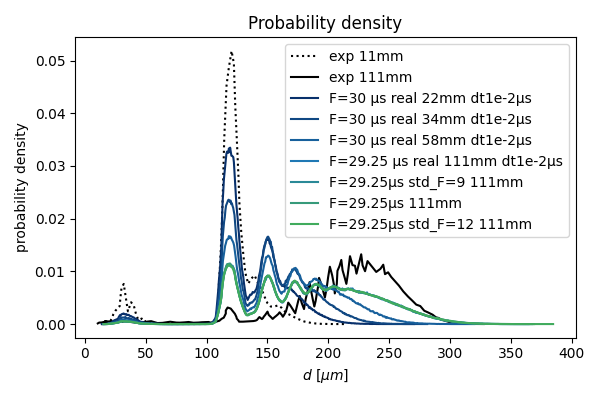

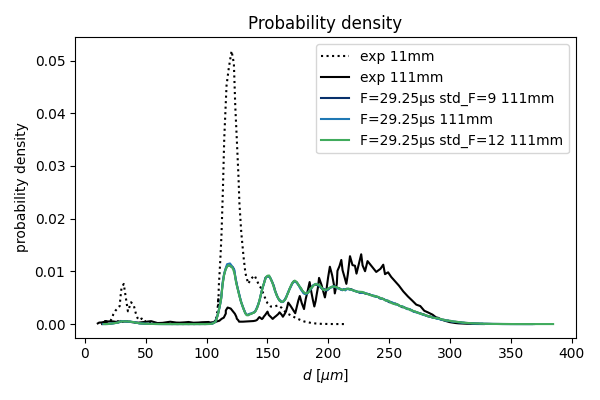

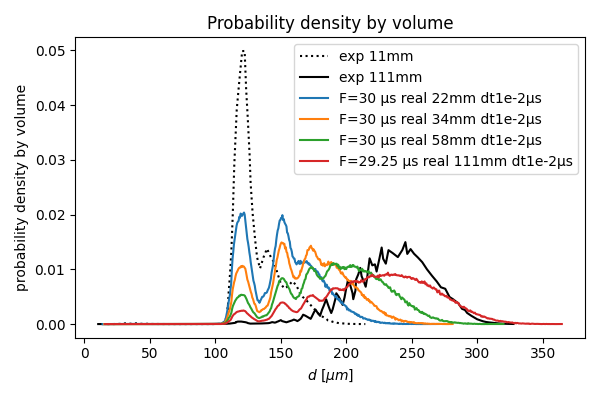

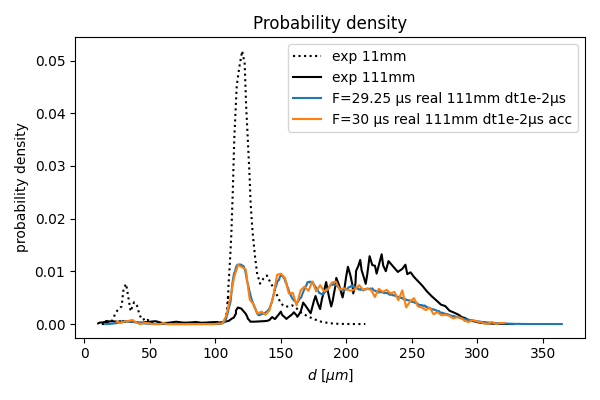

In [28]:
# plotProbabilityDensityByVolumeComp(all_simus_111mm)#, log = True)
# plotProbabilityDensityByVolumeComp(uniform_dist_list)#, log = True)
# plotProbabilityDensityComp(uniform_dist_list, title = "Uniform velocity distribution $V=[9, 11]m/s$", save_name="uniform_vel_dist", log = True)
# plotProbabilityDensityByVolumeComp([ColDist2x111mm])#, log = True)
plotProbabilityDensityComp([redo22mm, redo34mm, redo58mm,redo111mm, norm_time_std9_dist111mm, redo2_111mm, norm_time_std12_dist111mm], title = "Probability density", save_name="time_comps", gradient=True)#, log = True)
plotProbabilityDensityComp([ norm_time_std9_dist111mm, redo2_111mm, norm_time_std12_dist111mm], title = "Probability density", save_name="time_comps", gradient=True)#, log = True)
plotProbabilityDensityByVolumeComp([redo22mm, redo34mm, redo58mm,redo111mm]                       , save_name="time_comps")#, title = "")#, log = True)
# plotProbabilityDensityComp(all_simus_111mm)#, log = True)
plotProbabilityDensityComp([redo111mm, redo111mm_acc], title = "Probability density", save_name="drag_and_111")#, gradient=True)#, log = True)

# plotProbabilityDensityByVolumeComp(all_simus_111mm, log = True, lines=False)
# plotProbabilityDensityByVolumeCompRescaled(all_simus_111mm, log=True)
# plotProbabilityDensityByVolumeImageComp()

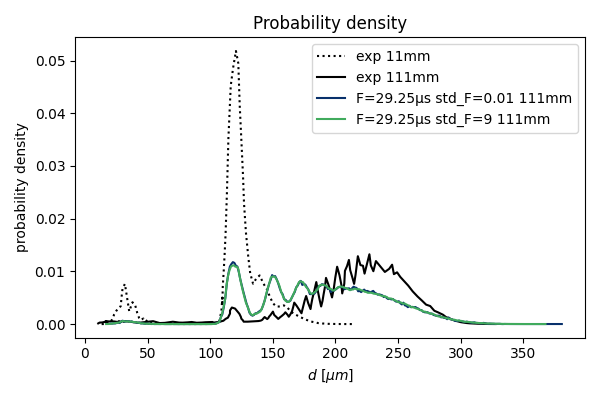

In [25]:
plotProbabilityDensityComp([norm_time_std001_dist111mm,norm_time_std9_dist111mm], title = "Probability density", save_name="std9", gradient=True)#, log = True)


In [ ]:
print ( 

_IncompleteInputError: incomplete input (3946693568.py, line 1)

In [ ]:
# TODO maximum droplet size given the distribution and window 
# How does the vmin and vmax impact the largest droplets that we can  get 

Optimized from your guess: m=2.481, t=11.223
Optimized from your guess: m=2.004, t=4.154
1.8372182803952426 -0.06104854350040542 2.301685786651806
1.180643039853288 4.999564170392217 2.350166625951509


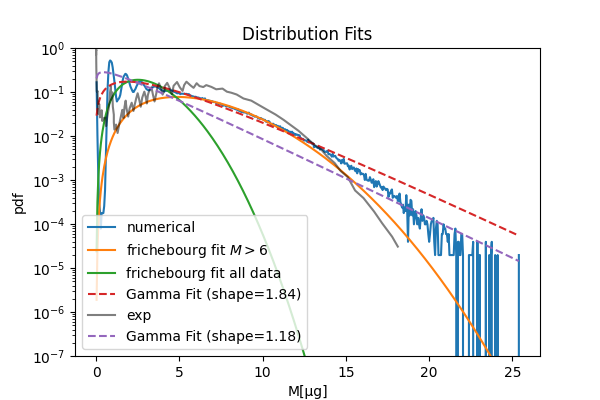

In [ ]:
from scipy.optimize import curve_fit
from scipy.stats import gamma
from frichebourg import *

bin_centers = redo111mm.m_prob_dist_bin_centers*1e9
probabilities = redo111mm.m_prob_density*1e-9

plt.figure(figsize=figure_size_cstm)
plt.plot(bin_centers,probabilities, label="numerical")
# plt.hist(raw_data, bins=b, weights=weights)#, edgecolor='black')

def frichebourgAnaRhoFit(M, m, t):
    Mp = M/(t**(2/3))
    return m*m/(pow(t,(4/3)))*frichebourgF(Mp)


nn = bin_centers > 6#probabilities < 35e-3
# popt, pcov = curve_fit(frichebourgAnaRhoFit, bin_centers[nn], probabilities[nn])

guess = [0.7, 10.0]
# 2. Add physical boundaries (m and t must be positive, and maybe t shouldn't exceed 50)
lower_bounds = [0.001, 0.001]
upper_bounds = [10.0, 50.0]

popt, pcov = curve_fit(
    frichebourgAnaRhoFit,
    bin_centers[nn],
    probabilities[nn],
    p0=guess,
    bounds=(lower_bounds, upper_bounds)
)

print(f"Optimized from your guess: m={popt[0]:.3f}, t={popt[1]:.3f}")
m_opt, t_opt = popt

# plt.plot(bin_centers[nn], probabilities[nn])
plt.plot(bin_centers, frichebourgAnaRhoFit(bin_centers, m_opt, t_opt), label = "frichebourg fit $M>6$")

guess = [0.7, 10.0]
# 2. Add physical boundaries (m and t must be positive, and maybe t shouldn't exceed 50)
lower_bounds = [0.001, 0.001]
upper_bounds = [10.0, 50.0]

popt, pcov = curve_fit(
    frichebourgAnaRhoFit,
    bin_centers,
    probabilities,
    p0=guess,
    bounds=(lower_bounds, upper_bounds)
)

print(f"Optimized from your guess: m={popt[0]:.3f}, t={popt[1]:.3f}")
m_opt, t_opt = popt
plt.plot(bin_centers, frichebourgAnaRhoFit(bin_centers, m_opt, t_opt), label = "frichebourg fit all data")
# plt.plot(bin_centers, frichebourgAnaRhoFit(bin_centers, 1/2, 12), label="hand fit")


bin_width = redo111mm.m_prob_dist_bin_centers[2] - redo111mm.m_prob_dist_bin_centers[1] # We need this to scale the Gamma PDF
r_data = redo111mm.m*1e9  
shape, loc, scale = gamma.fit(r_data)
print(shape, loc, scale)
gamma_pdf = gamma.pdf(bin_centers, shape, loc=loc, scale=scale)
scaled_gamma = gamma_pdf #* bin_width
plt.plot(bin_centers, scaled_gamma, label=f'Gamma Fit (shape={shape:.2f})', linestyle='--')
plt.plot(exp_111mm.m_prob_dist_bin_centers*1e9, exp_111mm.m_prob_density*1e-9, color = "k", alpha = 0.5, label = "exp")

bin_width = redo111mm.m_prob_dist_bin_centers[2] - redo111mm.m_prob_dist_bin_centers[1] # We need this to scale the Gamma PDF
r_data = np.array([m for m in redo111mm.m*1e9 if m > 5]  )
shape, loc, scale = gamma.fit(r_data)
print(shape, loc, scale)
gamma_pdf = gamma.pdf(bin_centers, shape, loc=0, scale=scale)
scaled_gamma = gamma_pdf #* bin_width
plt.plot(bin_centers, scaled_gamma, label=f'Gamma Fit (shape={shape:.2f})', linestyle='--')

plt.ylabel('pdf')
plt.ylim([1e-7, 1])
# plt.xlim([0,  20])
plt.yscale('log')
plt.xlabel("M[µg]")
plt.title('Distribution Fits')
plt.legend()
plt.savefig(figure_dir+"probability_fit.pdf")
plt.show()


Optimized from your guess: m=2.481, t=11.223
Optimized from your guess: m=2.004, t=4.154
Gamma fit all data: shape=1.837, loc=-0.061, scale=2.302
Gamma fit m>5: shape=1.181, loc=5.000, scale=2.350
Lognormal fit all data: shape=0.666, loc=-0.587, scale=3.858


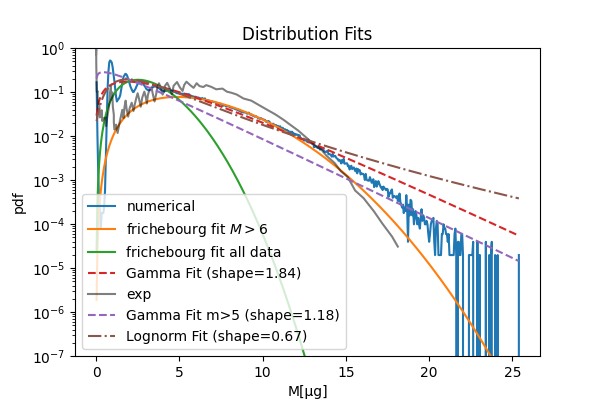

In [ ]:
from scipy.optimize import curve_fit
from scipy.stats import gamma, lognorm
import numpy as np
import matplotlib.pyplot as plt
from frichebourg import *

bin_centers = redo111mm.m_prob_dist_bin_centers*1e9
probabilities = redo111mm.m_prob_density*1e-9

plt.figure(figsize=figure_size_cstm)
plt.plot(bin_centers, probabilities, label="numerical")
# plt.hist(raw_data, bins=b, weights=weights)#, edgecolor='black')

def frichebourgAnaRhoFit(M, m, t):
    Mp = M/(t**(2/3))
    return m*m/(pow(t,(4/3)))*frichebourgF(Mp)

nn = bin_centers > 6 #probabilities < 35e-3
# popt, pcov = curve_fit(frichebourgAnaRhoFit, bin_centers[nn], probabilities[nn])

guess = [0.7, 10.0]
# Add physical boundaries (m and t must be positive, and maybe t shouldn't exceed 50)
lower_bounds = [0.001, 0.001]
upper_bounds = [10.0, 50.0]

popt, pcov = curve_fit(
    frichebourgAnaRhoFit,
    bin_centers[nn],
    probabilities[nn],
    p0=guess,
    bounds=(lower_bounds, upper_bounds)
)

print(f"Optimized from your guess: m={popt[0]:.3f}, t={popt[1]:.3f}")
m_opt, t_opt = popt

# plt.plot(bin_centers[nn], probabilities[nn])
plt.plot(bin_centers, frichebourgAnaRhoFit(bin_centers, m_opt, t_opt), label = "frichebourg fit $M>6$")

guess = [0.7, 10.0]
lower_bounds = [0.001, 0.001]
upper_bounds = [10.0, 50.0]

popt, pcov = curve_fit(
    frichebourgAnaRhoFit,
    bin_centers,
    probabilities,
    p0=guess,
    bounds=(lower_bounds, upper_bounds)
)

print(f"Optimized from your guess: m={popt[0]:.3f}, t={popt[1]:.3f}")
m_opt, t_opt = popt
plt.plot(bin_centers, frichebourgAnaRhoFit(bin_centers, m_opt, t_opt), label = "frichebourg fit all data")
# plt.plot(bin_centers, frichebourgAnaRhoFit(bin_centers, 1/2, 12), label="hand fit")

# --- Gamma Fit (All data) ---
bin_width = redo111mm.m_prob_dist_bin_centers[2] - redo111mm.m_prob_dist_bin_centers[1] 
r_data = redo111mm.m*1e9  
shape, loc, scale = gamma.fit(r_data)
print(f"Gamma fit all data: shape={shape:.3f}, loc={loc:.3f}, scale={scale:.3f}")
gamma_pdf = gamma.pdf(bin_centers, shape, loc=loc, scale=scale)
plt.plot(bin_centers, gamma_pdf, label=f'Gamma Fit (shape={shape:.2f})', linestyle='--')
plt.plot(exp_111mm.m_prob_dist_bin_centers*1e9, exp_111mm.m_prob_density*1e-9, color = "k", alpha = 0.5, label = "exp")

# --- Gamma Fit (m > 5) ---
bin_width = redo111mm.m_prob_dist_bin_centers[2] - redo111mm.m_prob_dist_bin_centers[1] 
r_data_filtered = np.array([m for m in redo111mm.m*1e9 if m > 5])
shape_f, loc_f, scale_f = gamma.fit(r_data_filtered)
print(f"Gamma fit m>5: shape={shape_f:.3f}, loc={loc_f:.3f}, scale={scale_f:.3f}")
gamma_pdf_f = gamma.pdf(bin_centers, shape_f, loc=0, scale=scale_f)
plt.plot(bin_centers, gamma_pdf_f, label=f'Gamma Fit m>5 (shape={shape_f:.2f})', linestyle='--')

# --- Lognormal Fit (All data) ---
shape_log, loc_log, scale_log = lognorm.fit(r_data)
print(f"Lognormal fit all data: shape={shape_log:.3f}, loc={loc_log:.3f}, scale={scale_log:.3f}")
lognorm_pdf = lognorm.pdf(bin_centers, shape_log, loc=loc_log, scale=scale_log)
plt.plot(bin_centers, lognorm_pdf, label=f'Lognorm Fit (shape={shape_log:.2f})', linestyle='-.')

plt.ylabel('pdf')
plt.ylim([1e-7, 1])
# plt.xlim([0,  20])
plt.yscale('log')
plt.xlabel("M[µg]")
plt.title('Distribution Fits')
plt.legend()
plt.savefig(figure_dir+"probability_fit.pdf")
plt.show()

📊 redo111mm Mass vs. Velocity Correlation: -0.0101


KeyboardInterrupt: 

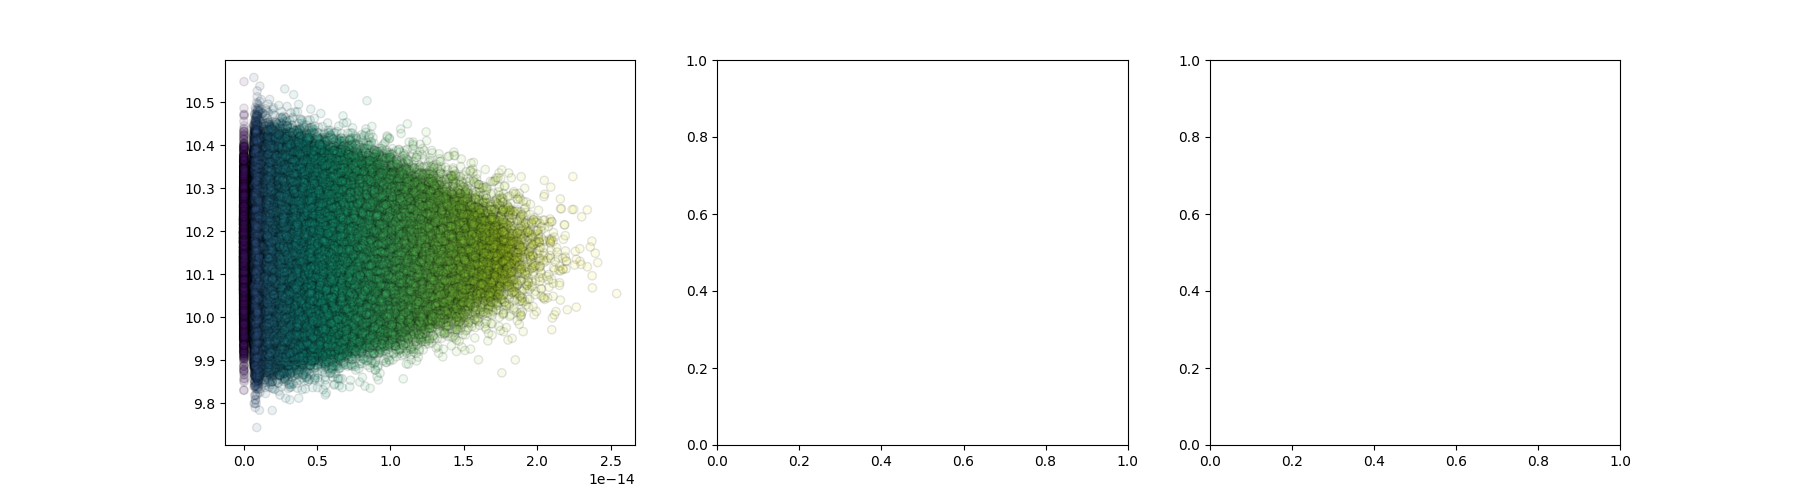

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re

# ==========================================
# 1. CONFIGURATION
# ==========================================
# Change this to the folder where your C code dumped the .dat files
# Create a DataFrame for our redo111mm dataset
df_redo = pd.DataFrame({
    'radius':  redo111mm.d/2,
    'velocity':redo111mm.v
})

# ==========================================
# 3. CALCULATE PHYSICS PROPERTIES
# ==========================================
RHO_WATER = 998.0  # kg/m^3

# Convert Radius to Volume to Mass
df_redo['radius_m'] = df_redo['radius'] * 1e-6
df_redo['volume_m3'] = (4.0 / 3.0) * np.pi * (df_redo['radius_m'] ** 3)
df_redo['mass_kg'] = RHO_WATER * df_redo['volume_m3']
df_redo['mass_ng'] = df_redo['mass_kg'] * 1e12  # Convert to nanograms

# Print Correlation Output
correlation = df_redo['mass_ng'].corr(df_redo['velocity'])
print(f"📊 redo111mm Mass vs. Velocity Correlation: {correlation:.4f}")

# ==========================================
# 4. PLOT 3-PANEL DASHBOARD
# ==========================================
# Widen the figure to accommodate 3 plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- PLOT 1: Velocity vs Mass Scatter ---
sns.scatterplot(
    data=df_redo, 
    x='mass_ng', 
    y='velocity', 
    hue='radius', 
    palette='viridis', 
    size='radius',
    sizes=(20, 200),
    alpha=0.1,
    edgecolor='black',
    ax=axes[0]
)
axes[0].set_title('Velocity vs. Mass (redo111mm)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mass (nanograms)', fontsize=11)
axes[0].set_ylabel('Velocity (m/s)', fontsize=11)
axes[0].legend(title='Radius (µm)')
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- PLOT 2: Standard (Number-Weighted) Velocity Distribution ---
# Notice we DO NOT use the `weights` parameter here. Every droplet counts as 1.
sns.histplot(
    data=df_redo,
    x='velocity',
    bins=30,
    kde=True,
    color='coral',
    edgecolor='black',
    ax=axes[1]
)
axes[1].set_title('Standard Velocity Dist (Count-Based)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Velocity (m/s)', fontsize=11)
axes[1].set_ylabel('Droplet Count (Frequency)', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].set_yscale('log')


# --- PLOT 3: Volume-Weighted Velocity Distribution ---
# Notice we DO use the `weights` parameter here. Large droplets spike the graph.
sns.histplot(
    data=df_redo,
    x='velocity',
    weights='volume_m3',  
    bins=30,
    kde=True,
    color='teal',
    edgecolor='black',
    ax=axes[2]
)
axes[2].set_title('Volume-Weighted Velocity Dist', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Velocity (m/s)', fontsize=11)
axes[2].set_ylabel('Volume Contribution', fontsize=11)
axes[2].grid(True, linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show()